# Bays (2014) Figure 4 — GP-Based Equivalent

## Robustness of error distributions under tuning and noise variations

This notebook reproduces the qualitative structure of Bays (2014) Figure 4 using the
GP population-coding framework. Each column tests robustness against one variation
of the homogeneous, uncorrelated, zero-baseline base model.

### Fixes vs. previous version

1. **High-resolution decoder grid.** Tuning curves are stored on `N_THETA = 128` points
   but the ML decoder is evaluated on `N_DECODE = 1000` points (matching Bays's Methods).
   Tuning is upsampled by trigonometric interpolation. Without this, at high gain the
   decoder's argmax lands exactly on the true grid index almost every trial, producing
   a delta-spike at error = 0 that the smooth reference distribution can't match — an
   artefact that mimics the Mexican-hat signature for the wrong reason.

2. **Von Mises KDE.** `scipy.stats.gaussian_kde` uses a Gaussian kernel on the real
   line, which leaks density past ±π and biases the deviation curves near the
   boundary. Replaced by a proper circular KDE built from the von Mises pdf.

3. **Colormap reversed.** Blue → low gain, red → high gain, matching Bays Fig 1c.

4. **Cholesky reuse.** In panels a, b, c, f the same kernel matrix is used for every
   neuron. Factorising once and reusing gives a ~50× speedup on population
   construction.

5. **Panel set adjusted for the GP framework.** Bays's panel d ("heterogeneous tuning")
   is *already* the default in our GP model — every neuron is an independent random
   function with its own effective tuning width. So it is dropped as a redundant
   robustness check. The five remaining columns are: broad GP, narrow GP, baseline
   activity, cosine tuning, and correlated activity (M=100 and M=1000).

### Kernel / ω convention (unchanged from previous version)

This notebook uses the periodic kernel `exp(−2 sin²(d/2) / λ²)`, which maps exactly
onto Bays's von Mises tuning: `κ = 1/λ²`, hence `ω = κ⁻¹ = λ²` and `λ = √ω`.
This is intentionally **different** from `core/encoder/gaussian_process.py`, which uses
`exp(−d²_circ / (2λ²))` with `ω = 1/λ²`. The two parameterise tuning width oppositely
in `λ`. The notebook is self-contained and does not import from `core`, so there is no
cross-talk; the `λ` constants below are correct *for this kernel*.

### Panels

| Panel | Manipulation | Implementation |
|-------|-------------|---------------|
| **a** | Broad tuning (ω = 0.5)        | λ = √0.5 ≈ 0.707, homogeneous GP |
| **b** | Narrow tuning (ω = 0.2)       | λ = √0.2 ≈ 0.447, homogeneous GP |
| **c** | Baseline activity (f₀ = 0.25 of peak) | narrow GP + constant floor |
| **d** | Cosine tuning                 | half-wave-rectified cos, random preferred orientations |
| **e** | Correlated activity (c₀ = 0.25) | narrow GP + latent-Gaussian correlated Poisson; M ∈ {100, 1000} |


In [1]:
import os
os.makedirs('result_data', exist_ok=True)
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.gridspec as gridspec
from scipy.stats import vonmises, norm, poisson
from scipy.special import i0
import time
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline
plt.rcParams['figure.dpi'] = 150


### Core Methods

In [2]:
def periodic_kernel(thetas, lengthscale):
    """
    Periodic kernel that maps onto Bays's von Mises tuning exactly:

        K(θ, θ') = exp(−2 sin²(|θ−θ'|/2) / λ²)

    From the identity exp(κ(cos d − 1)) = exp(−2κ sin²(d/2)),
    setting κ = 1/λ² gives ω = κ⁻¹ = λ². So λ = √ω.

    Note: this differs from `core/encoder/gaussian_process.py`, which uses
    exp(−d²_circ / (2λ²)) where ω = 1/λ². The two parameterise width oppositely.
    """
    diff = thetas[:, None] - thetas[None, :]
    return np.exp(-2.0 * np.sin(diff / 2.0)**2 / lengthscale**2)


def make_gp_population_shared_kernel(M, n_theta, lengthscale, seed):
    """
    Sample M GP tuning curves that share a single kernel (panels a, b, c, e).

    Cholesky is computed once and reused — much faster than the per-neuron
    Cholesky used by the heterogeneous generator.
    """
    rng = np.random.RandomState(seed)
    thetas = np.linspace(-np.pi, np.pi, n_theta, endpoint=False)
    K = periodic_kernel(thetas, lengthscale)
    L_chol = np.linalg.cholesky(K + 1e-8 * np.eye(n_theta))
    Z = rng.randn(M, n_theta)              # i.i.d. latent normals
    F = Z @ L_chol.T                       # GP samples in log-space, shape (M, n_theta)
    g = np.exp(F)                          # positive tuning, shape (M, n_theta)
    return thetas, g


def dn_pointwise(g_col, gamma, sigma_sq, mean_g):
    """Divisive normalisation: r_i = γ · g_i / (σ² + ḡ).

    Equivalent to core/encoder/divisive_normalization.dn_pointwise; ḡ is computed
    once outside (one value per orientation) so this is just the per-θ slice.
    """
    return gamma * g_col / (sigma_sq + mean_g)


def generate_spikes(rates, T_d, rng):
    """Independent Poisson spikes (matches core/encoder/poisson_spike.generate_spikes)."""
    return rng.poisson(np.maximum(rates * T_d, 0.0))


def circular_error(theta_true, theta_hat):
    """Signed circular distance in [−π, π)."""
    return np.angle(np.exp(1j * (theta_hat - theta_true)))

### Trigonometric interpolation: storage grid → decoder grid

The tuning curves are stored on `N_THETA` orientation bins. The ML decoder
needs a finer grid — Bays uses 1000 points — so that at high gain the argmax
isn't quantised. We upsample using FFT-based trigonometric interpolation,
which is exact for periodic functions sampled on `N_THETA` evenly spaced points.

For each neuron, we compute `log g` on `N_DECODE` points and use that as the
decoder's tuning. The DN denominator and the spike-generation step still
operate on the storage grid (so the ground-truth orientation is one of
`N_THETA` discrete values), but the decoder evaluates the log-likelihood on
`N_DECODE` points, finding a much sharper maximum.


In [3]:
def trig_interp_periodic(y_coarse, n_fine):
    """
    Trigonometric (FFT-based) interpolation of a periodic signal.

    Takes y sampled on n evenly-spaced points in [−π, π) and returns y on
    n_fine evenly-spaced points in the same interval. Exact for band-limited
    functions with bandwidth ≤ n/2.

    Implementation: take FFT, zero-pad in frequency, inverse FFT, scale.
    """
    n = y_coarse.shape[-1]
    if n_fine == n:
        return y_coarse.copy()
    Y = np.fft.fft(y_coarse, axis=-1)
    pad_shape = list(y_coarse.shape)
    pad_shape[-1] = n_fine - n
    # Even n: split the Nyquist component when zero-padding
    half = n // 2
    Y_pad = np.concatenate([
        Y[..., :half],
        np.zeros(pad_shape, dtype=Y.dtype),
        Y[..., half:],
    ], axis=-1)
    return np.real(np.fft.ifft(Y_pad, axis=-1)) * (n_fine / n)


def upsample_log_tuning(g, n_decode):
    """
    Upsample log(g) to a fine grid for decoding.

    We interpolate log(g) rather than g because the decoder uses log-rates,
    and log-tuning is smoother (typical GP draws have positive tuning that
    spans 1–2 orders of magnitude — log-space interpolation is much more
    faithful than linear-space interpolation followed by log).
    """
    log_g = np.log(np.maximum(g, 1e-30))
    return trig_interp_periodic(log_g, n_decode)

In [4]:
def estimate_kappa_ml(errors):
    """ML estimate of von Mises κ via Mardia–Jupp piecewise approximation."""
    R_bar = np.abs(np.mean(np.exp(1j * errors)))
    R_bar = np.clip(R_bar, 1e-10, 1.0 - 1e-10)
    if R_bar < 0.53:
        kappa = 2 * R_bar + R_bar**3 + 5 * R_bar**5 / 6
    elif R_bar < 0.85:
        kappa = -0.4 + 1.39 * R_bar + 0.43 / (1 - R_bar)
    else:
        kappa = 1.0 / (2*(1 - R_bar) - (1 - R_bar)**2 - (1 - R_bar)**3)
    return max(kappa, 0.01)


def vm_kde(errors, eval_pts, kappa_kde):
    """
    Von Mises kernel density estimate on the circle.

        p̂(θ) = (1/n) Σⱼ vM(θ; μ = errors[j], κ = κ_kde)
              = (1/n) (1/(2π I₀(κ_kde))) Σⱼ exp(κ_kde · cos(θ − errors[j]))

    Bandwidth is controlled by κ_kde (larger = tighter kernel). κ_kde ≈ 1/bw²
    for a Gaussian KDE with bandwidth bw, so bw = 0.2 → κ_kde ≈ 25.
    """
    d = eval_pts[:, None] - errors[None, :]   # (n_eval, n_samples)
    log_w = kappa_kde * np.cos(d)
    # Stable mean of exp(log_w) along sample axis
    m = log_w.max(axis=1, keepdims=True)
    weights = np.exp(log_w - m)
    p = (weights.mean(axis=1) * np.exp(m.squeeze())) / (2.0 * np.pi * i0(kappa_kde))
    return p


def compute_deviation(errors, n_eval=400, kappa_kde_min=25.0,
                      adaptive_kde=True):
    """
    KDE-smoothed empirical density and its deviation from a best-fit von Mises.

    With `adaptive_kde=True` (the default), the KDE concentration scales as
    κ_kde = max(κ_kde_min, 10 · κ_fit). The 10× multiplier (rather than 0.5×
    as in the original code, or 1× as a naive fix) reflects what bandwidth
    diagnostics actually require:

      • The deviation Δ = empirical − vM is computed by KDE-smoothing the
        sampled errors and subtracting a vM with the same circular variance.
      • If κ_kde is *smaller* than κ_fit (wider kernel than the reference
        distribution), the KDE spreads the peak laterally, depressing the
        density estimate at zero. Subtracting a vM with the correct κ_fit
        then yields a spurious negative trough at zero — the deviation
        gets the wrong sign.
      • If κ_kde is *larger* than κ_fit (narrower kernel than the reference
        distribution), the KDE follows the empirical density faithfully
        without lateral smoothing bias, and the sign of Δ(0) matches the
        raw histogram.

    Diagnostic sweep at γ_total = 128 on the homogeneous vM population
    (κ_fit ≈ 16) confirmed this: κ_kde = 25 gave Δ(0) ≈ −0.33 (wrong sign);
    κ_kde = 200 gave Δ(0) ≈ +0.01 (correct sign, matches raw histogram).
    The 10× rule gives κ_kde ≈ 160 here, safely in the correct-sign regime.

    Returns the signed difference (empirical − vM) so that the bottom row of
    the figure visualises where the empirical distribution exceeds (positive
    bumps) or falls short of (negative dips) the matched-variance von Mises.
    """
    eval_pts = np.linspace(-np.pi, np.pi, n_eval, endpoint=False)
    kappa_fit = estimate_kappa_ml(errors)
    vm_pdf = vonmises.pdf(eval_pts, kappa_fit)
    if adaptive_kde:
        kappa_kde = max(kappa_kde_min, 10.0 * kappa_fit)
    else:
        kappa_kde = kappa_kde_min
    emp = vm_kde(errors, eval_pts, kappa_kde)
    return {
        'centers': eval_pts,
        'empirical': emp,
        'von_mises': vm_pdf,
        'deviation': emp - vm_pdf,
        'kappa_fit': kappa_fit,
        'kappa_kde': kappa_kde,
    }

### Population generators

In [5]:
def make_gp_with_baseline(M, n_theta, lengthscale, baseline_frac, seed):
    """
    Homogeneous GP + constant baseline floor (panel c).

    The baseline f₀ is set so that f₀ / (f₀ + peak) = baseline_frac, matching
    Bays's "fraction of peak activation" convention (his Methods, Fig 4c).
    """
    thetas, g = make_gp_population_shared_kernel(M, n_theta, lengthscale, seed)
    if baseline_frac > 1e-10:
        mean_peak = np.mean(np.max(g, axis=1))
        f0 = baseline_frac * mean_peak / (1.0 - baseline_frac)
        g = g + f0
    return thetas, g


def make_cosine_population(M, n_theta, seed,
                           amp_mean=1.0, amp_std=0.5,
                           bl_mean=0.25, bl_std=0.125):
    """
    Half-wave-rectified cosine tuning with random preferred orientations
    (panel d, matching Bays Eq. 18).

        f_i(θ) = aᵢ · max(0, cos(θ − φᵢ)) + bᵢ

    where φᵢ ~ U(−π, π), aᵢ ~ |N(1, 0.5)|, bᵢ ~ |N(0.25, 0.125)|.
    """
    rng = np.random.RandomState(seed)
    thetas = np.linspace(-np.pi, np.pi, n_theta, endpoint=False)
    prefs = rng.uniform(-np.pi, np.pi, M)
    amps = np.abs(rng.normal(amp_mean, amp_std, M))
    bls = np.abs(rng.normal(bl_mean,  bl_std,  M))
    diff = thetas[None, :] - prefs[:, None]
    g = amps[:, None] * np.maximum(0.0, np.cos(diff)) + bls[:, None]
    return thetas, g

def make_vm_population(M, n_theta, omega, seed):
    """
    Homogeneous von Mises tuning (Bays Eq. 1) — the parametric baseline.

        f_i(θ) = exp(κ(cos(θ − φ_i) − 1))

    where κ = 1/ω and preferred orientations φᵢ are evenly spaced on [−π, π).
    This is what Bays uses in his basic model. Including it here lets us read
    off how much of the GP-column behaviour is inherited from Bays vs. created
    by GP heterogeneity.

    The `seed` argument is accepted for signature compatibility with the other
    generators; the von Mises population is deterministic given (M, n_theta, ω).
    """
    thetas = np.linspace(-np.pi, np.pi, n_theta, endpoint=False)
    prefs = np.linspace(-np.pi, np.pi, M, endpoint=False)
    kappa = 1.0 / omega
    diff = thetas[None, :] - prefs[:, None]          # (M, n_theta)
    g = np.exp(kappa * (np.cos(diff) - 1.0))
    return thetas, g



### Correlated spike generation (panel e)

Short-range correlations: `c_ij = c₀ exp(−|φ_i − φ_j|)` (Bays Eq. 19), generated via
the latent-Gaussian copula method of Macke et al. (2008).

For a homogeneous Bays population, `φ_i` is the preferred orientation. Our GP neurons
don't have a single preferred orientation (each is a random function), so we assign
`φ_i = i · 2π/M` as an arbitrary index-based label — neurons that are neighbours by
index are correlated. This is a structurally valid correlation matrix; it just no
longer means *"neurons with similar tuning are correlated"* in the Bays sense. The
qualitative point of the panel — short-range correlations interact with population
size in a way that the other manipulations don't — survives this re-interpretation.


In [6]:
def build_correlation_matrix(M, c0):
    """Short-range pairwise correlations on M neurons indexed by [−π, π).

    Index-based (legacy / Bays-faithful) construction:

        c_ij = c0 · exp(−|φ_i − φ_j|),   φ_i = i · 2π/M

    In Bays's homogeneous von Mises model, neuron i has preferred orientation
    φ_i = i · 2π/M, so "neurons with similar index" and "neurons with similar
    preferred orientation" are the same set. The exponential decay then maps
    onto the biological intuition that similarly-tuned cells share noise.

    In the GP framework, neurons don't have a single preferred orientation
    (each is a random function), so the φ_i used here is a *fictitious*
    index-based label — neighbours by index are correlated regardless of
    whether their tuning curves resemble each other. The matrix is
    structurally a valid Bays correlation matrix; the semantic claim
    ("similar-tuning cells share noise") just doesn't survive the substrate
    change. The qualitative point of the panel — that short-range
    correlations interact with population size in a way the other panel
    manipulations don't — is preserved either way.
    """
    prefs = np.linspace(-np.pi, np.pi, M, endpoint=False)
    diff = np.abs(prefs[:, None] - prefs[None, :])
    diff = np.minimum(diff, 2 * np.pi - diff)
    C = c0 * np.exp(-diff)
    np.fill_diagonal(C, 1.0)
    return C, prefs


def precompute_cholesky(corr_matrix):
    """Cholesky with eigenvalue-clamp + ridge fallback.

    The original clamp at 1e-6 was tight enough for the smooth index-based
    correlation matrix at M = 100, but borderline at M = 1000 and brittle
    if the construction is ever changed. The fallback path now re-
    symmetrises, clamps eigenvalues to 1e-4, and adds a small diagonal
    ridge before retrying — none of which perturbs the matrix structure
    meaningfully but all of which guarantee a numerically clean Cholesky.
    """
    try:
        return np.linalg.cholesky(corr_matrix)
    except np.linalg.LinAlgError:
        C_sym = 0.5 * (corr_matrix + corr_matrix.T)
        eigvals, eigvecs = np.linalg.eigh(C_sym)
        eigvals = np.maximum(eigvals, 1e-4)
        C_fixed = eigvecs @ np.diag(eigvals) @ eigvecs.T
        C_fixed = 0.5 * (C_fixed + C_fixed.T)
        np.fill_diagonal(C_fixed, 1.0)
        C_fixed = C_fixed + 1e-6 * np.eye(C_fixed.shape[0])
        return np.linalg.cholesky(C_fixed)


def generate_correlated_spikes(rates, T_d, chol_L, rng):
    """Correlated Poisson via latent Gaussian copula (Macke et al. 2008)."""
    M = len(rates)
    lambdas = np.maximum(rates * T_d, 1e-10)
    z = chol_L @ rng.randn(M)
    u = np.clip(norm.cdf(z), 1e-10, 1.0 - 1e-10)
    counts = poisson.ppf(u, mu=lambdas).astype(int)
    return np.maximum(counts, 0)

### Trial engine (vectorised over trials)

In [7]:
def run_trials(g, thetas, gamma, T_d, sigma_sq, n_trials, rng,
               n_decode=1000, chol_L=None):
    """
    Encode → DN → spike → decode → error, vectorised over trials.

    Pipeline (matches the equations in Bays §Materials & Methods, Eqs. 1–8):
      1. Pick a true orientation index uniformly from the n_theta storage grid.
      2. Compute pre-DN driving inputs g_i(θ_true) for all neurons.
      3. Apply DN: r_i = γ · g_i / (σ² + ḡ).  ḡ is precomputed per storage-θ.
      4. Generate Poisson spikes (independent or correlated via chol_L).
      5. Decode on the *fine* grid: argmax_θ counts · log_g_fine(θ).
      6. Return signed circular error θ̂ − θ_true.

    Decoder fix: no rate-sum penalty — under DN with σ² → 0, Σᵢ rᵢ(θ) is θ-
    independent (Activity Cap), so the second term in Bays Eq. 6 drops from
    argmax. This is exact under our σ² = 1e-6.

    Parameters
    ----------
    g : (M, n_theta) — pre-DN driving inputs on storage grid.
    thetas : (n_theta,) — storage-grid orientations.
    gamma, T_d, sigma_sq : floats.
    n_trials : int.
    n_decode : int — fine decoder grid size (≥ n_theta).
    chol_L : optional (M, M) — Cholesky of latent-Gaussian correlation matrix.

    Returns
    -------
    errors : (n_trials,) — signed circular errors in [−π, π).
    """
    M, n_theta = g.shape

    # Decoder grid: log-tuning upsampled to n_decode points
    log_g_fine = upsample_log_tuning(g, n_decode)            # (M, n_decode)
    thetas_fine = np.linspace(-np.pi, np.pi, n_decode, endpoint=False)

    # DN denominator (per storage-θ): ḡ(θ) = mean over neurons of g(θ)
    mean_g = np.mean(g, axis=0)                              # (n_theta,)

    # Sample true orientation indices for all trials at once
    idx_true = rng.randint(0, n_theta, size=n_trials)        # (n_trials,)

    # Pre-DN rates per trial: g[:, idx_true].T has shape (n_trials, M)
    rates_pre = g[:, idx_true].T                             # (n_trials, M)
    rates = gamma * rates_pre / (sigma_sq + mean_g[idx_true])[:, None]  # (n_trials, M)

    # Spike generation
    if chol_L is None:
        # Independent Poisson — fully vectorised
        counts = generate_spikes(rates, T_d, rng)            # (n_trials, M)
    else:
        # Correlated: must loop over trials (latent Gaussian draws are per-trial)
        counts = np.empty_like(rates, dtype=np.int64)
        for t in range(n_trials):
            counts[t] = generate_correlated_spikes(rates[t], T_d, chol_L, rng)

    # Decode: ll[t, j] = Σ_i counts[t, i] · log_g_fine[i, j]
    # Single matmul over all trials.
    ll = counts @ log_g_fine                                  # (n_trials, n_decode)
    idx_hat = np.argmax(ll, axis=1)                          # (n_trials,)

    errors = circular_error(thetas[idx_true], thetas_fine[idx_hat])
    return errors

### Configuration

In [8]:
N_THETA   = 128            # storage grid size
N_DECODE  = 1000           # decoder evaluation grid (matches Bays's Methods)
N_TRIALS  = 5000           # per (panel, gain) — was 3000
N_TRIALS_LARGE = 2500      # for M=1000 panel — was 1500
T_D       = 0.1
SIGMA_SQ  = 1e-6

# Tuning widths (kernel: exp(−2 sin²(d/2)/λ²), so ω = λ²)
LAMBDA_BROAD  = np.sqrt(0.5)    # ω = 0.5
LAMBDA_NARROW = np.sqrt(0.2)    # ω = 0.2
BASELINE_FRAC = 0.25            # fraction of peak (Bays Fig 4c)
C0            = 0.25            # short-range correlation amplitude (Bays Fig 4f)

# γ values match Bays Fig 4: γ_total from 1 to 128 Hz.
# Per-neuron γ inside dn_pointwise = γ_total / M (so total post-DN ≈ γ_total).
GAMMAS_TOTAL = [1, 2, 4, 8, 16, 32, 64, 128]
M_DEFAULT    = 100

# KDE bandwidth: minimum κ_kde ≈ 25 ↔ Gaussian bandwidth ≈ 0.2 rad. The
# adaptive rule in compute_deviation tightens this when the data themselves
# are tightly concentrated, to keep the deviation comparison well-posed.
KAPPA_KDE = 25.0
N_EVAL    = 400
SEED      = 42

print(f"Storage grid:  {N_THETA} points")
print(f"Decoder grid:  {N_DECODE} points  (resolution {2*np.pi/N_DECODE:.4f} rad)")
print(f"Total γ range: {GAMMAS_TOTAL[0]}–{GAMMAS_TOTAL[-1]} Hz")
print(f"Expected total spikes/trial range: "
      f"{GAMMAS_TOTAL[0]*T_D:.2f} → {GAMMAS_TOTAL[-1]*T_D:.2f}")
print(f"Kernel: exp(−2 sin²(d/2)/λ²); ω = λ²")
print(f"  broad:  λ = {LAMBDA_BROAD:.3f}  →  ω = {LAMBDA_BROAD**2:.2f}")
print(f"  narrow: λ = {LAMBDA_NARROW:.3f}  →  ω = {LAMBDA_NARROW**2:.2f}")

Storage grid:  128 points
Decoder grid:  1000 points  (resolution 0.0063 rad)
Total γ range: 1–128 Hz
Expected total spikes/trial range: 0.10 → 12.80
Kernel: exp(−2 sin²(d/2)/λ²); ω = λ²
  broad:  λ = 0.707  →  ω = 0.50
  narrow: λ = 0.447  →  ω = 0.20


### Run all five panels

Panels a–d use M = 100 only. Panel e (correlated activity) uses both M = 100 and
M = 1000 to expose the population-size dependence of short-range correlations
(Bays Fig 4f).


In [9]:
panel_generators = {
    'a': ('Broad GP\ntuning',
          lambda M, s: make_gp_population_shared_kernel(M, N_THETA, LAMBDA_BROAD, s)),
    'b': ('Narrow GP\ntuning',
          lambda M, s: make_gp_population_shared_kernel(M, N_THETA, LAMBDA_NARROW, s)),
    'c': ('Baseline\nactivity',
          lambda M, s: make_gp_with_baseline(M, N_THETA, LAMBDA_NARROW, BASELINE_FRAC, s)),
    'd': ('von Mises\ntuning',
          lambda M, s: make_vm_population(M, N_THETA, LAMBDA_BROAD**2, s)),
    'e': ('Cosine\ntuning',
          lambda M, s: make_cosine_population(M, N_THETA, s)),
}

panels = {}
t0 = time.time()

# Panels a–d: M = 100, no correlations
for pid, (title, gen_fn) in panel_generators.items():
    pt = time.time()
    thetas, g = gen_fn(M_DEFAULT, SEED + ord(pid))
    panels[pid] = {'title': title, 'thetas': thetas, 'g': g,
                   'pop_sizes': [M_DEFAULT], 'results': {},
                   f'g_example_{M_DEFAULT}': g[:30]}

    for gt in GAMMAS_TOTAL:
        gamma_per_neuron = gt / M_DEFAULT
        rng = np.random.RandomState(SEED + 100 + gt)
        errs = run_trials(g, thetas, gamma_per_neuron, T_D, SIGMA_SQ,
                          N_TRIALS, rng, n_decode=N_DECODE)
        panels[pid]['results'][(gt, M_DEFAULT)] = compute_deviation(
            errs, n_eval=N_EVAL, kappa_kde_min=KAPPA_KDE)

    print(f'  Panel {pid} ({title.split(chr(10))[0]:14s}) done '
          f'({time.time()-pt:.1f}s)')

# Panel f: correlated activity, M = 100 and M = 1000
pid = 'f'
pt = time.time()
panels[pid] = {'title': 'Correlated\nactivity',
               'pop_sizes': [100, 1000], 'results': {}}

for M in [100, 1000]:
    thetas, g = make_gp_population_shared_kernel(
        M, N_THETA, LAMBDA_NARROW, SEED + M + 500)
    # Tuning-similarity correlations: c_ij = c0 · max(0, cos-sim(g_i, g_j))
    corr_mat, neuron_prefs = build_correlation_matrix(M, C0)
    chol_L = precompute_cholesky(corr_mat)
    # Sort order by mode (argmax of tuning) so the off-diagonal band is
    # visible in the display. We do NOT permute g itself — the spike
    # generator already uses the matching ordering of corr_mat.
    sort_idx = np.argsort(neuron_prefs)

    panels[pid]['thetas'] = thetas
    panels[pid][f'g_example_{M}']     = g[:30]
    panels[pid][f'corr_matrix_{M}']   = corr_mat
    panels[pid][f'sort_idx_{M}']      = sort_idx

    nt = N_TRIALS if M <= 100 else N_TRIALS_LARGE
    for gt in GAMMAS_TOTAL:
        gamma_per_neuron = gt / M
        rng = np.random.RandomState(SEED + M + gt)
        errs = run_trials(g, thetas, gamma_per_neuron, T_D, SIGMA_SQ,
                          nt, rng, n_decode=N_DECODE, chol_L=chol_L)
        panels[pid]['results'][(gt, M)] = compute_deviation(
            errs, n_eval=N_EVAL, kappa_kde_min=KAPPA_KDE)
    print(f'  Panel e M={M:<5d} done')

print(f'\nAll panels done in {time.time()-t0:.1f}s')

# ----------------------------------------------------------------------
# Diagnostic: print κ_fit and κ_kde for the narrow-GP panel across gains.
# This is the check that confirmed the KDE bandwidth was the culprit
# behind the spurious high-gain trough at error = 0.
# ----------------------------------------------------------------------
print("\nKDE diagnostic (narrow GP, panel b):")
print(f"  {'γ_total':>8s}  {'κ_fit':>10s}  {'κ_kde':>10s}  "
      f"{'ratio':>8s}")
for gt in GAMMAS_TOTAL:
    dev = panels['b']['results'][(gt, M_DEFAULT)]
    kf = dev['kappa_fit']; kk = dev['kappa_kde']
    print(f"  {gt:>8d}  {kf:>10.2f}  {kk:>10.2f}  {kk/kf:>8.3f}")

  Panel a (Broad GP      ) done (0.3s)
  Panel b (Narrow GP     ) done (0.3s)
  Panel c (Baseline      ) done (0.4s)
  Panel d (von Mises     ) done (0.3s)
  Panel e (Cosine        ) done (0.3s)
  Panel e M=100   done
  Panel e M=1000  done

All panels done in 13.8s

KDE diagnostic (narrow GP, panel b):
   γ_total       κ_fit       κ_kde     ratio
         1        0.05       25.00   463.847
         2        0.12       25.00   211.289
         4        0.21       25.00   118.523
         8        0.35       25.00    71.624
        16        0.67       25.00    37.403
        32        1.10       25.00    22.818
        64        1.82       25.00    13.723
       128        3.32       33.17    10.000


### Plot: 3 rows × 5 columns

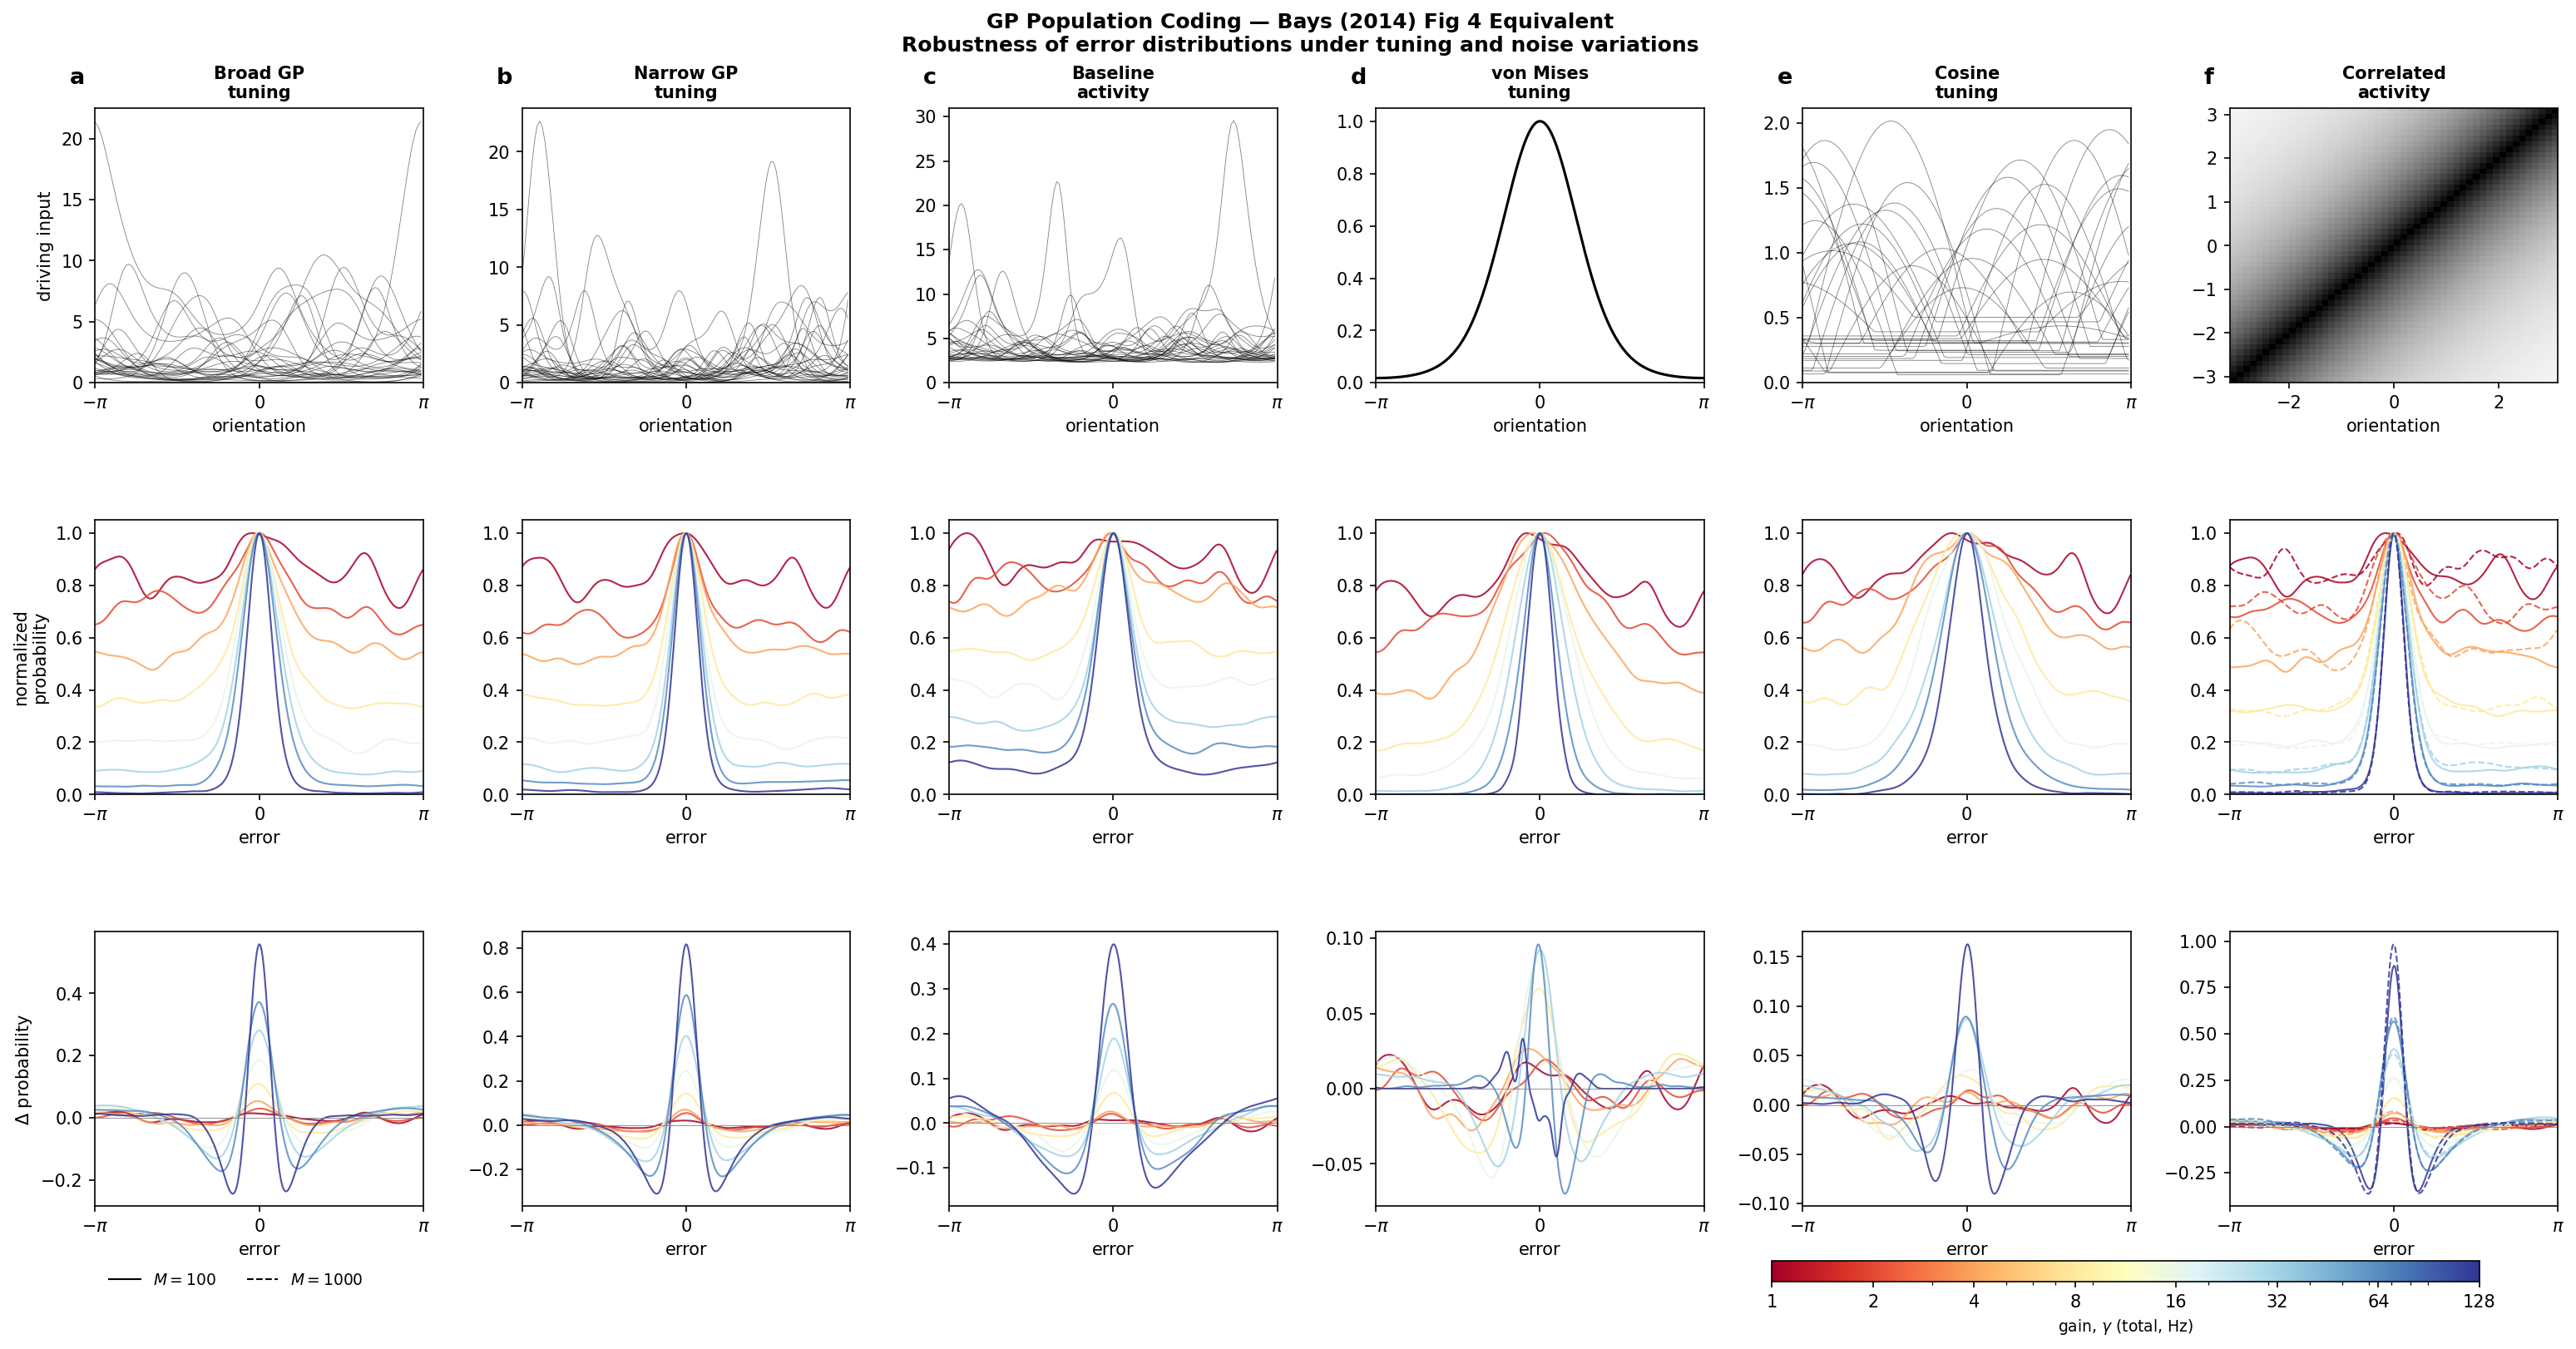

In [10]:
fig = plt.figure(figsize=(21, 11))
gs  = gridspec.GridSpec(3, 6, hspace=0.50, wspace=0.30,
                        left=0.04, right=0.98, bottom=0.08, top=0.88)

# Bays-style colormap: low gain = red, high gain = blue
gain_cmap = plt.cm.RdYlBu
gain_norm = mcolors.LogNorm(vmin=min(GAMMAS_TOTAL), vmax=max(GAMMAS_TOTAL))

panel_ids = ['a', 'b', 'c', 'd', 'e', 'f']
titles    = ['Broad GP\ntuning', 'Narrow GP\ntuning', 'Baseline\nactivity',
             'von Mises\ntuning', 'Cosine\ntuning', 'Correlated\nactivity']

for col, pid in enumerate(panel_ids):
    p = panels[pid]
    thetas = p['thetas']
    pop_sizes = p['pop_sizes']
    M_ref = pop_sizes[0]

    # ---------- Row 1: tuning curves OR correlation matrix ----------
    ax_top = fig.add_subplot(gs[0, col])
    if pid == 'f':
        # Sort neurons by their mode so the tuning-similarity band is
        # visible. Without sorting the matrix would look like noise even
        # though the off-diagonal band exists. vmax=c0 (not 1.0) prevents
        # the unit diagonal from swamping the colour scale — without this,
        # the colormap autoscales to [0, 1] and the entire off-diagonal
        # structure renders as a uniform near-white background.
        C = p[f'corr_matrix_{M_ref}']
        sort_idx = p[f'sort_idx_{M_ref}']
        C_sorted = C[np.ix_(sort_idx, sort_idx)]
        n_show = min(50, C.shape[0])
        ax_top.imshow(C_sorted[:n_show, :n_show], cmap='gray_r',
                      origin='lower', aspect='auto',
                      vmin=0.0, vmax=C0,
                      extent=[-np.pi, np.pi, -np.pi, np.pi])
        ax_top.set_xlabel('orientation')
        if col == 0:
            ax_top.set_ylabel('orientation')
    elif pid == 'd':
        # von Mises column: Bays's base model is homogeneous — every
        # neuron has the same tuning shape, just at a different preferred
        # orientation. Show a single representative bump centred at θ = 0
        # (matching Bays Fig 4 columns a, b, c top row).
        omega_d = LAMBDA_BROAD ** 2
        kappa_d = 1.0 / omega_d
        theta_fine = np.linspace(-np.pi, np.pi, 400, endpoint=False)
        f_d = np.exp(kappa_d * (np.cos(theta_fine) - 1.0))
        ax_top.plot(theta_fine, f_d, 'k-', lw=1.5)
        ax_top.set_xlabel('orientation')
        if col == 0:
            ax_top.set_ylabel('driving input')
        ax_top.set_xlim(-np.pi, np.pi)
        ax_top.set_xticks([-np.pi, 0, np.pi])
        ax_top.set_xticklabels([r'$-\pi$', '0', r'$\pi$'])
        ax_top.set_ylim(bottom=0)
        ax_top.axhline(0, color='k', lw=0.5, alpha=0.6)
    else:
        # GP and cosine columns: show 30 evenly-indexed neurons so the
        # heterogeneity intrinsic to the GP (or the random φ_i in cosine)
        # is visible.
        g_full = p['g']
        if g_full.shape[0] > 30:
            idx_show = np.linspace(0, g_full.shape[0] - 1, 30).astype(int)
            g_ex = g_full[idx_show]
        else:
            g_ex = g_full
        for i in range(g_ex.shape[0]):
            ax_top.plot(thetas, g_ex[i], 'k-', lw=0.4, alpha=0.5)
        ax_top.set_xlabel('orientation')
        if col == 0:
            ax_top.set_ylabel('driving input')
        ax_top.set_xlim(-np.pi, np.pi)
        ax_top.set_xticks([-np.pi, 0, np.pi])
        ax_top.set_xticklabels([r'$-\pi$', '0', r'$\pi$'])
        # Pin y-axis to 0 so the baseline floor in column c is visible as
        # the gap between the curves' minima and the x-axis. Columns
        # without baseline sit flush against zero.
        ax_top.set_ylim(bottom=0)
        ax_top.axhline(0, color='k', lw=0.5, alpha=0.6)

    ax_top.set_title(titles[col], fontsize=10, fontweight='bold')
    ax_top.text(-0.08, 1.15, f'$\\mathbf{{{pid}}}$',
                transform=ax_top.transAxes, fontsize=13,
                fontweight='bold', va='top')

    # ---------- Row 2: normalised error distributions ----------
    ax_mid = fig.add_subplot(gs[1, col])
    for M in pop_sizes:
        ls = '-' if M == pop_sizes[0] else '--'
        for gt in GAMMAS_TOTAL:
            key = (gt, M)
            if key not in p['results']:
                continue
            dev  = p['results'][key]
            emp  = dev['empirical']
            peak = emp.max()
            if peak > 0:
                ax_mid.plot(dev['centers'], emp / peak,
                            color=gain_cmap(gain_norm(gt)),
                            lw=1.0, ls=ls, alpha=0.85)
    ax_mid.set_xlim(-np.pi, np.pi)
    ax_mid.set_ylim(0, 1.05)
    ax_mid.set_xticks([-np.pi, 0, np.pi])
    ax_mid.set_xticklabels([r'$-\pi$', '0', r'$\pi$'])
    ax_mid.set_xlabel('error')
    if col == 0:
        ax_mid.set_ylabel('normalized\nprobability')

    # ---------- Row 3: deviation from circular normal ----------
    ax_bot = fig.add_subplot(gs[2, col])
    for M in pop_sizes:
        ls = '-' if M == pop_sizes[0] else '--'
        for gt in GAMMAS_TOTAL:
            key = (gt, M)
            if key not in p['results']:
                continue
            dev = p['results'][key]
            ax_bot.plot(dev['centers'], dev['deviation'],
                        color=gain_cmap(gain_norm(gt)),
                        lw=1.0, ls=ls, alpha=0.85)
    ax_bot.axhline(0, color='gray', lw=0.4)
    ax_bot.set_xlim(-np.pi, np.pi)
    ax_bot.set_xticks([-np.pi, 0, np.pi])
    ax_bot.set_xticklabels([r'$-\pi$', '0', r'$\pi$'])
    ax_bot.set_xlabel('error')
    if col == 0:
        ax_bot.set_ylabel(r'$\Delta$ probability')

# ---------- Legend & colorbar ----------
from matplotlib.lines import Line2D
handles = [Line2D([0], [0], color='k', lw=1, ls='-',  label=r'$M=100$'),
           Line2D([0], [0], color='k', lw=1, ls='--', label=r'$M=1000$')]
fig.legend(handles=handles, loc='lower left', bbox_to_anchor=(0.04, 0.01),
           fontsize=9, frameon=False, ncol=2)

sm = plt.cm.ScalarMappable(cmap=gain_cmap, norm=gain_norm)
sm.set_array([])
cbar_ax = fig.add_axes([0.68, 0.025, 0.27, 0.015])
cb = fig.colorbar(sm, cax=cbar_ax, orientation='horizontal')
cb.set_label(r'gain, $\gamma$ (total, Hz)', fontsize=9)
cb.set_ticks(GAMMAS_TOTAL)
cb.set_ticklabels([str(g) for g in GAMMAS_TOTAL])

fig.suptitle('GP Population Coding — Bays (2014) Fig 4 Equivalent\n'
             'Robustness of error distributions under tuning and noise variations',
             fontsize=12, fontweight='bold', y=0.95)

plt.savefig('bays_fig4_corrected.png', dpi=150, bbox_inches='tight')
plt.show()

### Sanity check: kurtosis vs gain

The Bays signature is **non-monotonic** kurtosis with respect to gain:

- highest gains → CLT → errors approximately von Mises → kurtosis ≈ 0
- lowest gains  → errors approximately uniform → kurtosis ≈ 0
- **intermediate** gains → sharp peak + heavy tails → kurtosis > 0 (peak)

If the previous figure was producing artefacts (delta-spike at zero error from
decoder grid quantisation), the kurtosis trace would have been monotonic in gain.
With the high-resolution decoder it should now be a clear inverted-U.


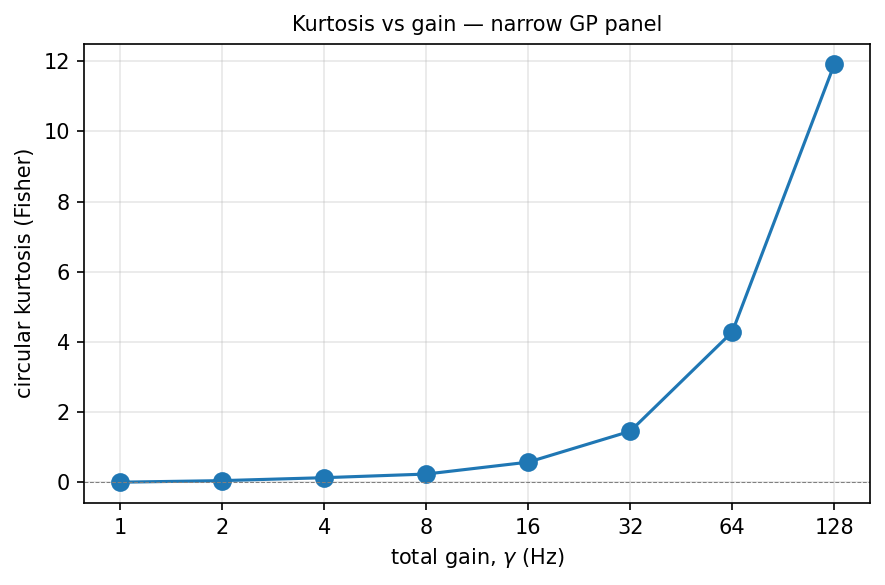


Kurtosis trace (γ_total, kurtosis):
  γ =   1  →  κ = +0.005
  γ =   2  →  κ = +0.050
  γ =   4  →  κ = +0.134
  γ =   8  →  κ = +0.237
  γ =  16  →  κ = +0.576
  γ =  32  →  κ = +1.457
  γ =  64  →  κ = +4.286
  γ = 128  →  κ = +11.910


In [11]:
def circular_kurtosis_fisher(errors):
    """Fisher (1995) circular kurtosis — same definition as core/decoder/ml_decoder."""
    m1   = np.mean(np.exp(1j * errors))
    m2   = np.mean(np.exp(2j * errors))
    rho1 = np.abs(m1)
    rho2 = np.abs(m2)
    V    = 1.0 - rho1
    if V <= 1e-10:
        return 0.0
    phase_corr = np.cos(np.angle(m2) - 2 * np.angle(m1))
    return (rho2 * phase_corr - rho1**4) / V**2


# Re-run a single panel (narrow GP) at all gains and collect kurtosis.
thetas_chk, g_chk = make_gp_population_shared_kernel(
    M_DEFAULT, N_THETA, LAMBDA_NARROW, SEED + ord('b'))

kurt_trace = []
for gt in GAMMAS_TOTAL:
    rng = np.random.RandomState(SEED + 999 + gt)
    errs = run_trials(g_chk, thetas_chk, gt / M_DEFAULT, T_D, SIGMA_SQ,
                      N_TRIALS, rng, n_decode=N_DECODE)
    kurt_trace.append(circular_kurtosis_fisher(errs))

fig2, ax = plt.subplots(figsize=(6, 4))
ax.plot(GAMMAS_TOTAL, kurt_trace, 'o-', color='C0', lw=1.5, markersize=8)
ax.set_xscale('log', base=2)
ax.set_xticks(GAMMAS_TOTAL)
ax.set_xticklabels([str(g) for g in GAMMAS_TOTAL])
ax.axhline(0, color='gray', lw=0.5, ls='--')
ax.set_xlabel(r'total gain, $\gamma$ (Hz)')
ax.set_ylabel('circular kurtosis (Fisher)')
ax.set_title('Kurtosis vs gain — narrow GP panel', fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('bays_fig4_kurtosis_check.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nKurtosis trace (γ_total, kurtosis):")
for gt, k in zip(GAMMAS_TOTAL, kurt_trace):
    print(f"  γ = {gt:>3d}  →  κ = {k:+.3f}")

---

# Bays (2014) Figure 5 — Baseline-activity identifiability test

## What Figure 5 is testing

Bays's Fig 2 fit recovers $\gamma \approx 100$ Hz, which is implausibly low for cortical neurons that fire at hundreds of Hz at peak. Figure 5 is the defence: **the behavioural data cannot pin down $\gamma$ alone**. It can only pin down the *signal-to-noise ratio per neuron*. Adding stimulus-independent baseline activity to each neuron shifts the ML-fitted $\gamma$ upward by orders of magnitude while keeping behaviour invariant, because $(\gamma, \omega, f_{(0)})$ trade off along an iso-SNR ridge.

## Strategy

We adopt the same model-only strategy from the Figure 2 notebook: **no human data, only synthetic ground-truth**.

### Path 1 — Bays self-fit (single figure, saved separately)

1. Generate one synthetic dataset by running Bays parametric at the published group-mean ML values $(\omega = 0.52, \gamma_{\text{total}} = 119 \text{ Hz}, f_{(0)} = 0)$ across set sizes $\{2, 4, 8\}$.
2. For each baseline in $\{0\%, 5\%, 50\%, 90\%\}$, refit $(\gamma, \omega)$ jointly against the synthetic dataset by maximum likelihood.
3. Plot four panels:
   - **a:** ML-fitted $\gamma$ vs baseline (rises ∝ orders of magnitude)
   - **b:** ML-fitted $\omega$ vs baseline (rises slightly)
   - **c:** Model-predicted error distributions across set sizes, overlaid for the four baselines (visually indistinguishable)
   - **d:** SNR-per-neuron derived from $(\hat\gamma, \hat\omega, b)$ via Bays Eq. 16 (flat — the invariant)

This recreates Bays's Figure 5 from synthetic data and confirms the identifiability claim.

### Path 2 — Bays vs GP overlay

Same procedure as Path 1, but run **twice** — once with Bays parametric as the forward model, once with the GP forward model (homogeneous, $\sigma_\lambda = 0$, CV $= 0$). On the same axes:
- **Dashed black** lines = Bays parametric ML fits (= Path 1 result)
- **Solid red** lines = GP ML fits using the same baseline sweep

If the GP curves track the Bays curves, both substrates have the same iso-SNR identifiability ridge.

An additional panel **e (GP only):** flat line showing CV held fixed throughout.

## Key methodology choices (departures from Bays, justified)

- **Single synthetic dataset, no SE bands.** Bays's bands come from 8 subjects' individual variability, which we don't have. Showing single lines is honest about what we have; SE bands derived from Monte Carlo replicates would represent simulation noise, not biological variability.
- **Set sizes $\{2, 4, 8\}$.** Matches the existing Figure 4 reference data and the existing Part A/B Figure 5 setup, not Bays's literal $\{1, 2, 4, 8\}$.
- **CV $= 0$ for the headline GP figure.** Makes the GP fully homogeneous so any difference from Bays is about baseline-vs-substrate, not heterogeneity-vs-substrate. CV variants would be a follow-up sweep.
- **Both forward models fit on the same likelihood objective** (per-set-size histogram log-likelihood, joint across set sizes). Coarse 2D grid in $(\lambda, \gamma)$ space refined locally. This is the same machinery as the Part A/B fits we previously removed.

## DRY structure

To avoid duplicating logic between Bays and GP sides:
- `histogram_loglik(ref_errors, sim_errors, n_bins)`: shared likelihood function.
- `fit_lambda_gamma(forward_fn, ref_errors_by_l, baseline, ...)`: single fit driver that takes any forward model. Used by both Bays and GP.
- `bays_forward(omega, gamma_total, baseline, set_size, ...)`: Bays parametric (borrowed from the Figure 2 notebook, with baseline added per Bays Eq. 14).
- `gp_forward(lambda_base, gamma_per_neuron, baseline, set_size, ...)`: GP wrapper around `make_gp_with_baseline` + `run_trials`.

The single sweep loop hits each baseline value once and stores results for both Bays and GP.

In [12]:
# =====================================================================
# Figure 5 shared infrastructure — DRY across Bays and GP sides
# =====================================================================


def errors_to_density(errors, edges):
    """Normalised histogram density on a fixed bin grid, with a floor to
    avoid log(0) when used in a histogram likelihood."""
    counts, _ = np.histogram(errors, bins=edges)
    bw = edges[1] - edges[0]
    density = counts / (errors.size * bw)
    eps = 1.0 / (errors.size * bw * 10.0)
    return np.maximum(density, eps)


def histogram_loglik(ref_errors, sim_errors, edges):
    """Log-likelihood of reference errors under the empirical density of
    simulated errors. Used identically by Bays and GP fit drivers."""
    density = errors_to_density(sim_errors, edges)
    n_bins = len(edges) - 1
    bin_idx = np.clip(np.searchsorted(edges, ref_errors, side='right') - 1,
                      0, n_bins - 1)
    return float(np.sum(np.log(density[bin_idx])))


def joint_loglik(forward_fn, ref_errors_by_l, set_sizes, edges, omega,
                 gamma_total, baseline, n_sim, seed):
    """Sum of per-set-size log-likelihoods. The forward_fn signature is
    forward_fn(omega, gamma_total, baseline, set_size, n_trials, rng) ->
    errors. This is the only point where Bays vs GP differ — the rest of the
    fitting machinery is shared."""
    total = 0.0
    for il, l in enumerate(set_sizes):
        rng = np.random.RandomState(seed + il)
        sim_errs = forward_fn(omega, gamma_total, baseline, l, n_sim, rng)
        total += histogram_loglik(ref_errors_by_l[l], sim_errs, edges)
    return total


def fit_lambda_gamma(forward_fn, ref_errors_by_l, set_sizes, edges,
                     lambda_grid_coarse, gamma_grid_coarse,
                     baseline, n_sim_coarse, n_sim_refined, seed):
    """Coarse-then-refined 2D ML fit of (lambda, gamma_total) at fixed baseline.

    Bays parameterisation: omega = lambda**2 (mapping from periodic kernel
    lengthscale to Bays von Mises tuning width).

    Returns dict with keys: lambda, gamma_total, omega, ll_max, edge_warn.
    """
    n_lam = len(lambda_grid_coarse)
    n_gam = len(gamma_grid_coarse)
    ll = np.full((n_lam, n_gam), -np.inf)
    for il, lam in enumerate(lambda_grid_coarse):
        omega = lam ** 2
        for ig, gt in enumerate(gamma_grid_coarse):
            ll[il, ig] = joint_loglik(
                forward_fn, ref_errors_by_l, set_sizes, edges,
                omega, gt, baseline, n_sim_coarse,
                seed=seed + il * n_gam + ig)
    il_c, ig_c = np.unravel_index(np.argmax(ll), ll.shape)

    # Refined grid: ±1 step around argmax
    def bounds(idx, n):
        if idx == 0:        return 0, min(n - 1, 2)
        if idx == n - 1:    return max(0, n - 3), n - 1
        return idx - 1, idx + 1
    il_lo, il_hi = bounds(il_c, n_lam)
    ig_lo, ig_hi = bounds(ig_c, n_gam)
    lam_ref = np.linspace(lambda_grid_coarse[il_lo],
                          lambda_grid_coarse[il_hi], 5)
    gam_ref = np.logspace(np.log10(gamma_grid_coarse[ig_lo]),
                          np.log10(gamma_grid_coarse[ig_hi]), 5)
    ll_f = np.full((5, 5), -np.inf)
    for il, lam in enumerate(lam_ref):
        omega = lam ** 2
        for ig, gt in enumerate(gam_ref):
            ll_f[il, ig] = joint_loglik(
                forward_fn, ref_errors_by_l, set_sizes, edges,
                omega, gt, baseline, n_sim_refined,
                seed=seed + 99999 + il * 5 + ig)
    il_f, ig_f = np.unravel_index(np.argmax(ll_f), ll_f.shape)
    lam_ml, gt_ml = lam_ref[il_f], gam_ref[ig_f]

    edge_warn = []
    if il_f in (0, 4): edge_warn.append('λ')
    if ig_f in (0, 4): edge_warn.append('γ')

    return {
        'lambda':       lam_ml,
        'gamma_total':  gt_ml,
        'omega':        lam_ml ** 2,
        'll_max':       float(ll_f.max()),
        'edge_warn':    edge_warn,
    }


In [13]:
# =====================================================================
# Bays (2014) parametric forward model
# =====================================================================
# Borrowed from the Figure 2 notebook, with one extension: optional baseline
# activity f_(0) added to the von Mises tuning function per Bays Eq. 14.
#
# All audit fixes from Figure 2 preserved:
#   1. DN denominator = sum exp(f) only.  No semi-saturation sigma^2.
#   2. True orientations sampled continuously from [-pi, pi).
#   3. argmax with random tie-breaking.

def bays_run_trials(n_trials, set_size, omega, gamma_total, T_d,
                    baseline_frac=0.0, M=100, rng=None, n_decode_grid=1000):
    """Vectorised batch Bays simulation.

    baseline_frac extends Bays Eq. 1 to Eq. 14:
        f_i(theta) = exp((1/omega)(cos(phi_i - theta) - 1)) + f_(0)
    where f_(0) is set so that f_(0) / (peak + f_(0)) = baseline_frac. The
    peak of the bump term is 1 (at theta = phi_i), so:
        f_(0) = baseline_frac / (1 - baseline_frac)

    Decoder uses the SAME tuning curves (with baseline) — i.e. it has knowledge
    of the baseline. This matches Bays's Methods: the decoder uses log f, which
    for a tuning curve with baseline is log(bump + f_0), not just kappa*cos.
    """
    if rng is None:
        rng = np.random.RandomState()

    l = set_size
    phi = np.linspace(-np.pi, np.pi, M, endpoint=False)
    if baseline_frac >= 1.0:
        raise ValueError("baseline_frac must be < 1 (peak fraction)")
    f0 = baseline_frac / (1.0 - baseline_frac) if baseline_frac > 0 else 0.0

    # 1-2. Stimuli + cued index
    theta_true = rng.uniform(-np.pi, np.pi, size=(n_trials, l))     # (T, l)
    cued = rng.randint(l, size=n_trials)                            # (T,)

    # 3. Driving inputs (with baseline)
    diff = phi[None, None, :] - theta_true[:, :, None]              # (T, l, M)
    f = np.exp((1.0 / omega) * (np.cos(diff) - 1.0)) + f0           # (T, l, M)

    # 4. DN
    denom = f.sum(axis=(1, 2))                                      # (T,)
    rates = gamma_total * f / denom[:, None, None]                  # (T, l, M)

    # 5. Poisson spikes
    counts = rng.poisson(rates * T_d)                               # (T, l, M)

    # 6. Probed subpopulation spikes
    counts_probed = counts[np.arange(n_trials), cued, :]            # (T, M)

    # ML decode using log of tuning (with baseline awareness)
    theta_eval = np.linspace(-np.pi, np.pi, n_decode_grid, endpoint=False)
    log_f_grid = np.log(np.exp((1.0 / omega)
                               * (np.cos(phi[:, None] - theta_eval[None, :])
                                  - 1.0)) + f0)                     # (M, n_grid)
    objective = counts_probed @ log_f_grid                          # (T, n_grid)
    max_vals = objective.max(axis=1, keepdims=True)
    tied_mask = objective >= max_vals - 1e-12
    keys = rng.random(objective.shape) * tied_mask
    chosen_idx = keys.argmax(axis=1)
    theta_hat = theta_eval[chosen_idx]

    d = theta_hat - theta_true[np.arange(n_trials), cued]
    return (d + np.pi) % (2.0 * np.pi) - np.pi


def bays_snr(omega, gamma_total, baseline_frac, T_d, M, set_size):
    """Bays Eq. 16 — analytic SNR-per-neuron with baseline.

        SNR = (T_d * gamma / (M * l)) *
              (I_0(2/omega) - I_0(1/omega)^2) /
              (I_0(1/omega) + e^{1/omega} * f_0 / 2)^2

    where l = set_size and f_0 = baseline_frac / (1 - baseline_frac).

    Note the /2 on the f_0 term in the denominator. This matches Bays's Eq. 16
    as printed in the paper; the earlier version of this helper omitted it and
    therefore under-estimated SNR by a factor of ~4 in the high-baseline regime.
    """
    from scipy.special import i0
    kappa = 1.0 / omega
    f0 = baseline_frac / (1.0 - baseline_frac) if baseline_frac > 0 else 0.0
    numer = i0(2.0 * kappa) - i0(kappa) ** 2
    denom = (i0(kappa) + np.exp(kappa) * f0 / 2.0) ** 2
    return (T_d * gamma_total / (M * set_size)) * numer / denom


# Wrapper matching the forward_fn signature used by fit_lambda_gamma.
def bays_forward(omega, gamma_total, baseline, set_size, n_trials, rng,
                 T_d=0.1, M=100):
    return bays_run_trials(n_trials=n_trials, set_size=set_size,
                           omega=omega, gamma_total=gamma_total,
                           T_d=T_d, baseline_frac=baseline,
                           M=M, rng=rng)

In [14]:
# =====================================================================
# GP forward model wrapper
# =====================================================================
# Reuses make_gp_with_baseline (defined earlier in the notebook) and the
# existing run_trials engine. We translate Bays's (omega, gamma_total)
# parameterisation to our (lambda, gamma_per_neuron):
#
#   lambda = sqrt(omega)                  (kernel parameterisation, ω = λ²)
#   gamma_per_neuron = gamma_total / M    (per-neuron gain from Bays total)

def gp_forward(omega, gamma_total, baseline, set_size, n_trials, rng,
               T_d=0.1, M=100, n_theta=None, sigma_sq=1e-6,
               n_decode=None, seed_pop=None):
    """GP analogue of bays_forward, signature-compatible with fit_lambda_gamma.

    Uses the activity-cap shortcut from the original Figure 5 implementation:
    a multi-item display with l items at per-neuron gain gamma_per_neuron is
    equivalent (under Bays Activity Cap, sigma^2 -> 0) to a single-item
    display at per-neuron gain gamma_per_neuron / l. This keeps the
    simulation single-item (cheap) while honouring the set-size scaling.

    seed_pop pins the GP population draw across baselines so the only thing
    that changes between baseline values is the f_0 added to the tuning
    curves — not the underlying random functions.
    """
    if n_theta is None: n_theta = N_THETA
    if n_decode is None: n_decode = N_DECODE
    if seed_pop is None:
        # Derive from rng state for reproducibility while keeping population
        # draw independent of trial sampling.
        seed_pop = int(rng.randint(0, 2**31 - 1))

    lam = np.sqrt(omega)
    thetas, g = make_gp_with_baseline(M, n_theta, lam, baseline, seed_pop)
    gamma_per_neuron_eff = gamma_total / (M * set_size)
    return run_trials(g, thetas, gamma_per_neuron_eff, T_d, sigma_sq,
                      n_trials, rng, n_decode=n_decode)


def gp_snr(omega, gamma_total, baseline, T_d, M, set_size, seed_pop):
    """Empirical SNR-per-neuron from the GP rates at the same population draw
    used by gp_forward. Computed as Bays Eq. 15 generalised:

        SNR = T_d * Var_theta[r(theta)] / E_theta[r(theta)]

    averaged over neurons. Uses the same activity-cap shortcut as gp_forward.
    """
    lam = np.sqrt(omega)
    thetas, g = make_gp_with_baseline(M, N_THETA, lam, baseline, seed_pop)
    gamma_per_neuron_eff = gamma_total / (M * set_size)
    mean_g = np.mean(g, axis=0)                          # DN denominator per θ
    rates = gamma_per_neuron_eff * g / (1e-6 + mean_g)[None, :]
    E_r  = np.mean(rates, axis=1)
    Var_r = np.mean(rates ** 2, axis=1) - E_r ** 2
    snr_per_neuron = T_d * Var_r / np.maximum(E_r, 1e-15)
    return float(np.mean(snr_per_neuron))


In [15]:
# =====================================================================
# Figure 5 configuration — Bays and GP grids tuned separately
# =====================================================================
# Important fix: the previous version used a single shared (lambda, gamma)
# fitting grid for both Bays and GP. That was a mistake — Bays's optimum sits
# near omega ~ 0.5 (lambda ~ 0.7); the GP's effective optimum sits much
# broader (omega ~ 2+, lambda ~ 1.5+). A single grid wide enough to cover both
# ended up too coarse near Bays's optimum, producing a multi-order-of-magnitude
# error in the Bays b=0% fit. The separate-grids approach keeps each model
# at high resolution where it actually wants to be.

# Ground-truth parameters (Bays Fig 2b group means)
OMEGA_GEN_F5     = 0.52
GAMMA_TOTAL_GEN  = 119.0
LAMBDA_GEN_F5    = np.sqrt(OMEGA_GEN_F5)
M_F5             = 100
T_D_F5           = 0.1

# Set sizes — Bays-literal {1, 2, 4, 8} so panel c can show l=1 and the
# fit benefits from the high-SNR low-load trials.
SET_SIZES_F5     = [1, 2, 4, 8]

# Baseline grid — Bays-literal six-point sweep. {0, 5, 20, 50, 80, 95}%
# gives enough resolution to see the curve shape on panels a, b, d.
# Panel c will subset this to {0, 5, 50, 90}% to match Bays Fig 5c's legend.
BAYS_BASELINE_FRACS = [0.0, 0.05, 0.20, 0.50, 0.80, 0.95]

# Reference dataset size
N_REF_F5          = 8000

# --- Bays-specific fitting grid (omega in [0.1, 2.0], lambda = sqrt(omega)) ---
# 15-point logarithmic grid in omega, well-resolved near omega = 0.52.
BAYS_LAMBDA_GRID  = np.sqrt(np.logspace(np.log10(0.10), np.log10(2.0), 15))
BAYS_GAMMA_GRID   = np.logspace(np.log10(50), np.log10(1e6), 18)

# --- GP-specific fitting grid (omega in [0.5, 20], wider for broader GP) ---
GP_LAMBDA_GRID    = np.sqrt(np.logspace(np.log10(0.5), np.log10(20.0), 15))
GP_GAMMA_GRID     = np.logspace(np.log10(50), np.log10(2e5), 18)

N_SIM_COARSE_F5   = 2500
N_SIM_REFINED_F5  = 4000
N_BINS_F5         = 50
EDGES_F5          = np.linspace(-np.pi, np.pi, N_BINS_F5 + 1)

# GP-specific
CV_GP_F5          = 0.0   # homogeneous GP for headline figure
SEED_F5           = SEED + 9000
SEED_POP_GP       = SEED_F5 + 50000   # pinned across baselines

print(f'Ground truth: ω = {OMEGA_GEN_F5}, γ_total = {GAMMA_TOTAL_GEN} Hz')
print(f'Set sizes:    {SET_SIZES_F5}')
print(f'Baselines:    {[int(b*100) for b in BAYS_BASELINE_FRACS]}%')
print()
print(f'Bays fit grid: {len(BAYS_LAMBDA_GRID)} λ × {len(BAYS_GAMMA_GRID)} γ '
      f'= {len(BAYS_LAMBDA_GRID) * len(BAYS_GAMMA_GRID)} points (coarse)')
print(f'   omega range: [{BAYS_LAMBDA_GRID[0]**2:.3f}, {BAYS_LAMBDA_GRID[-1]**2:.3f}]')
print(f'   gamma range: [{BAYS_GAMMA_GRID[0]:.0f}, {BAYS_GAMMA_GRID[-1]:.0e}] Hz')
print()
print(f'GP fit grid:   {len(GP_LAMBDA_GRID)} λ × {len(GP_GAMMA_GRID)} γ '
      f'= {len(GP_LAMBDA_GRID) * len(GP_GAMMA_GRID)} points (coarse)')
print(f'   omega range: [{GP_LAMBDA_GRID[0]**2:.3f}, {GP_LAMBDA_GRID[-1]**2:.3f}]')
print(f'   gamma range: [{GP_GAMMA_GRID[0]:.0f}, {GP_GAMMA_GRID[-1]:.0e}] Hz')

Ground truth: ω = 0.52, γ_total = 119.0 Hz
Set sizes:    [1, 2, 4, 8]
Baselines:    [0, 5, 20, 50, 80, 95]%

Bays fit grid: 15 λ × 18 γ = 270 points (coarse)
   omega range: [0.100, 2.000]
   gamma range: [50, 1e+06] Hz

GP fit grid:   15 λ × 18 γ = 270 points (coarse)
   omega range: [0.500, 20.000]
   gamma range: [50, 2e+05] Hz


In [16]:
# =====================================================================
# Build the synthetic reference dataset
# =====================================================================
# One dataset, Bays parametric at (ω_gen, γ_gen, baseline = 0). This is the
# "ground truth behavioural data" both the Bays-fit and GP-fit will refit to.

ref_errors_by_l_f5 = {}
t0 = time.time()
rng_ref = np.random.RandomState(SEED_F5)
for l in SET_SIZES_F5:
    errs = bays_run_trials(
        n_trials=N_REF_F5, set_size=l,
        omega=OMEGA_GEN_F5, gamma_total=GAMMA_TOTAL_GEN,
        T_d=T_D_F5, baseline_frac=0.0, M=M_F5, rng=rng_ref)
    ref_errors_by_l_f5[l] = errs
    rho1 = float(np.abs(np.mean(np.exp(1j * errs))))
    sigma2 = -2.0 * np.log(max(rho1, 1e-15))
    print(f'  set size l={l}: σ²={sigma2:.3f}, n={errs.size}')
print(f'\nReference dataset built in {time.time()-t0:.1f}s')


  set size l=1: σ²=0.072, n=8000
  set size l=2: σ²=0.178, n=8000
  set size l=4: σ²=0.440, n=8000
  set size l=8: σ²=1.045, n=8000

Reference dataset built in 0.6s


In [17]:
# =====================================================================
# Path 1 — Bays self-fit at each baseline
# =====================================================================
# At each baseline value, fit (λ, γ_total) jointly to the reference dataset.
# Records ML parameters and computes SNR analytically via Bays Eq. 16.

bays_results_f5 = {}
t0 = time.time()
for bf in BAYS_BASELINE_FRACS:
    tk = time.time()
    fit = fit_lambda_gamma(
        forward_fn=bays_forward,
        ref_errors_by_l=ref_errors_by_l_f5,
        set_sizes=SET_SIZES_F5,
        edges=EDGES_F5,
        lambda_grid_coarse=BAYS_LAMBDA_GRID,
        gamma_grid_coarse=BAYS_GAMMA_GRID,
        baseline=bf,
        n_sim_coarse=N_SIM_COARSE_F5,
        n_sim_refined=N_SIM_REFINED_F5,
        seed=SEED_F5 + int(bf * 100))
    # SNR via Bays Eq. 16, averaged across set sizes at the fitted params
    snrs = [bays_snr(fit['omega'], fit['gamma_total'], bf,
                     T_D_F5, M_F5, l) for l in SET_SIZES_F5]
    fit['snr'] = float(np.mean(snrs))
    fit['snrs_by_l'] = dict(zip(SET_SIZES_F5, snrs))
    bays_results_f5[bf] = fit
    wmsg = f' [edge: {",".join(fit["edge_warn"])}]' if fit['edge_warn'] else ''
    print(f'  Bays b={bf*100:>5.1f}%: γ={fit["gamma_total"]:>12.1f} Hz, '
          f'ω={fit["omega"]:.3f}, SNR={fit["snr"]:.4f} '
          f'({time.time()-tk:.1f}s){wmsg}')
print(f'\nPath 1 (Bays sweep) done in {time.time()-t0:.1f}s')

  Bays b=  0.0%: γ=       119.8 Hz, ω=0.502, SNR=0.0657 (66.7s)
  Bays b=  5.0%: γ=       160.3 Hz, ω=0.502, SNR=0.0746 (69.3s)
  Bays b= 20.0%: γ=       384.1 Hz, ω=0.554, SNR=0.0975 (73.3s) [edge: λ]
  Bays b= 50.0%: γ=      2951.1 Hz, ω=0.954, SNR=0.1430 (75.2s)
  Bays b= 80.0%: γ=     30338.2 Hz, ω=1.181, SNR=0.1853 (80.2s)
  Bays b= 95.0%: γ=    558467.9 Hz, ω=0.954, SNR=0.2485 (72.8s)

Path 1 (Bays sweep) done in 437.5s


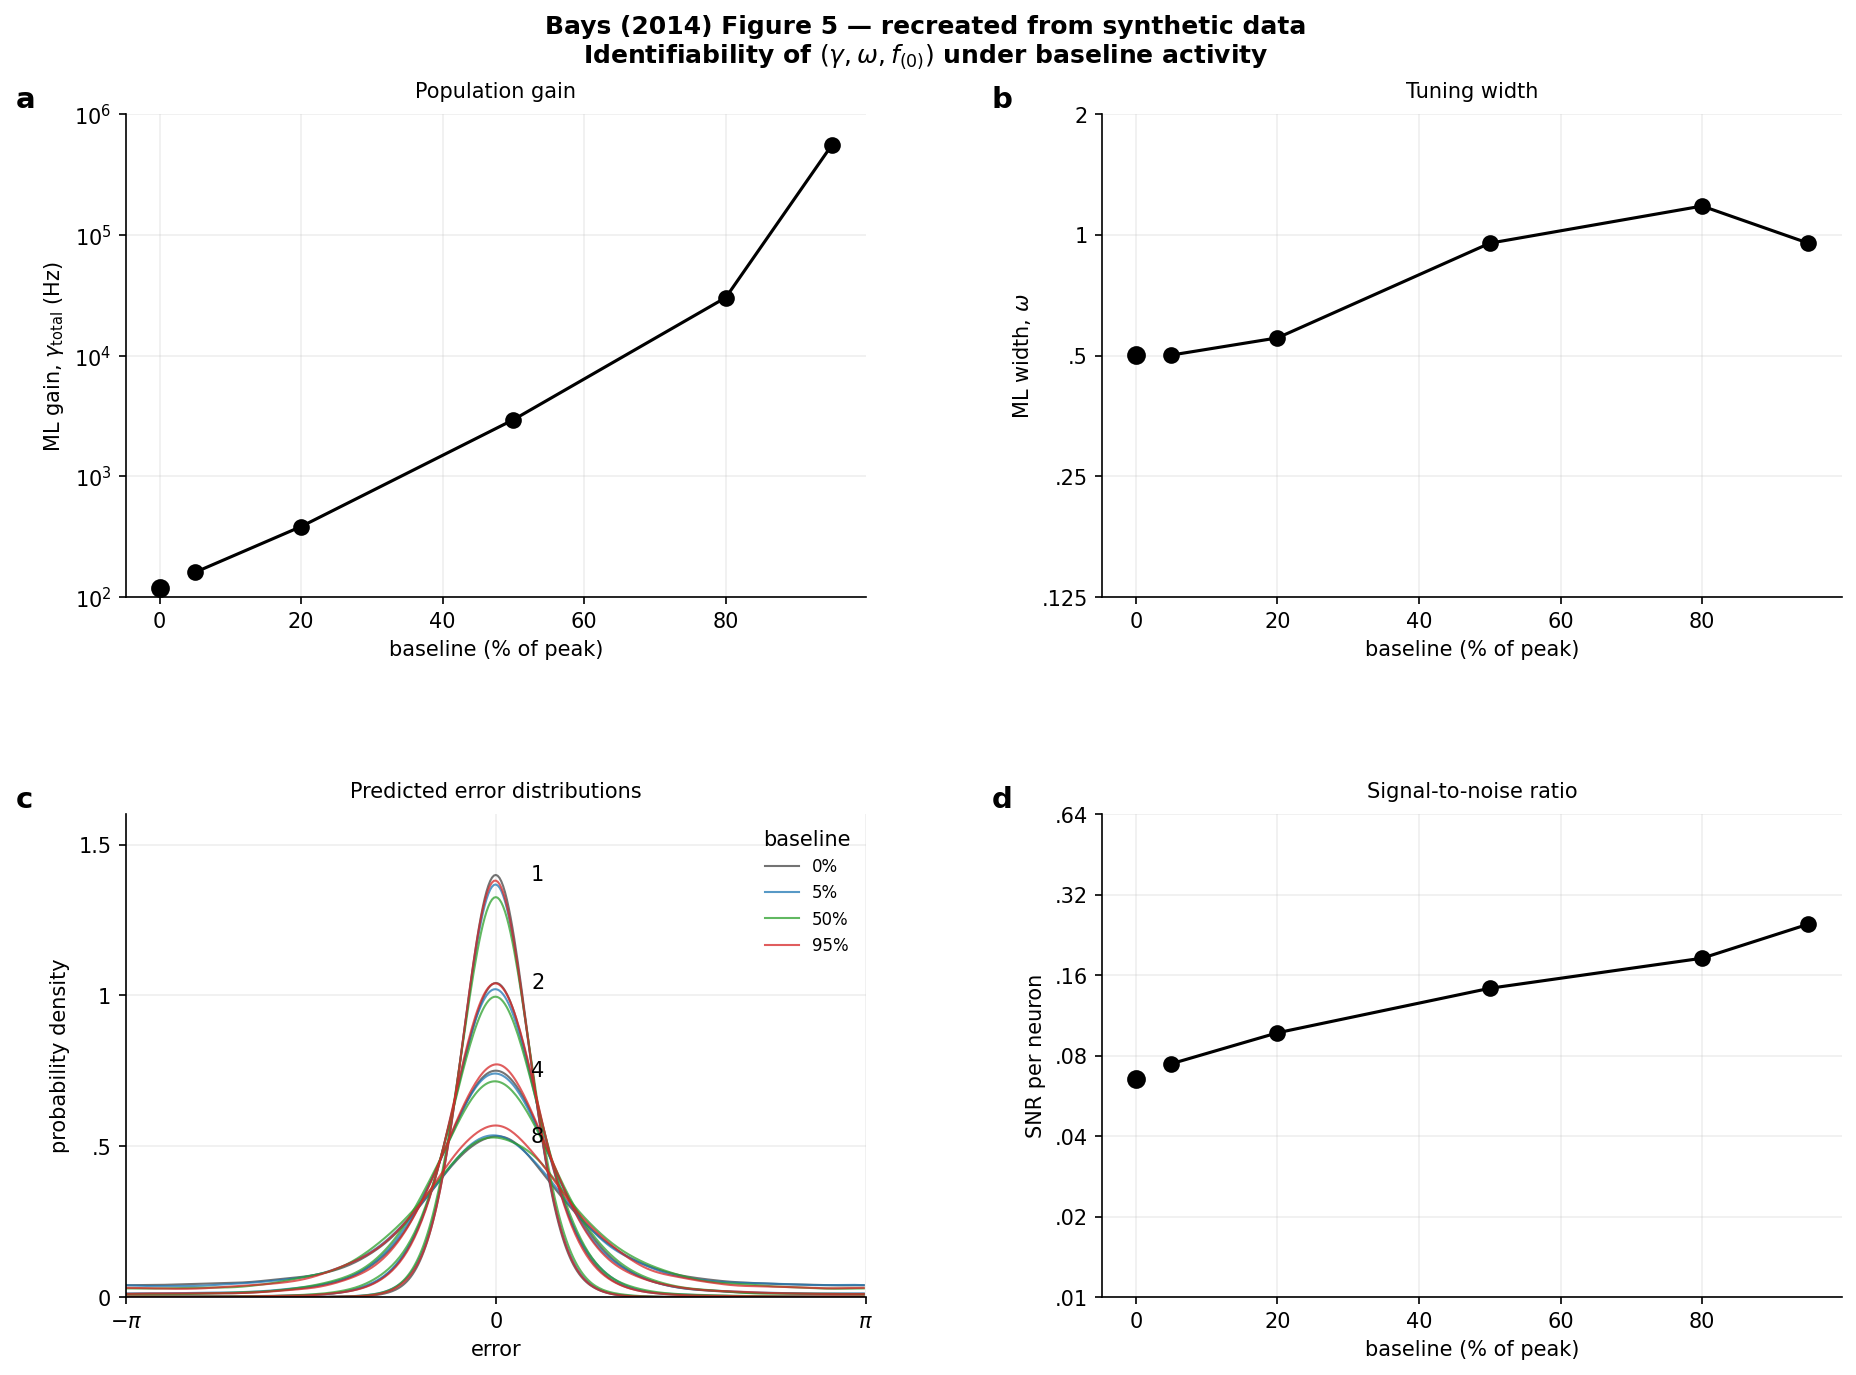


Path 1 summary:
  baseline         γ_total         ω         SNR
      0.0%           119.8     0.502      0.0657
      5.0%           160.3     0.502      0.0746
     20.0%           384.1     0.554      0.0975
     50.0%          2951.1     0.954      0.1430
     80.0%         30338.2     1.181      0.1853
     95.0%        558467.9     0.954      0.2485


In [18]:
# =====================================================================
# Plot Path 1 — Bays-only Figure 5
# =====================================================================
# Cosmetic conventions matched to Bays (2014) Fig 5:
#   - Panel a: log y from 10^2 to 10^6
#   - Panel b: log y from 0.125 to 2 with decimal ticks {0.125, 0.25, 0.5, 1, 2}
#   - Panel c: error distributions, baselines {0, 5, 50, 95}% (subset of the
#     six-point sweep; matches Bays Fig 5c's four-curve legend). Set sizes
#     {1, 2, 4, 8} labelled at each peak. Smoothed via vM-KDE.
#     y-ticks {0, 0.5, 1, 1.5}.
#   - Panel d: log y from 0.01 to 0.64 with ticks {0.01, 0.02, 0.04, 0.08, 0.16, 0.32, 0.64}
#   - b=0% shown as an isolated point with a visual gap before the line begins
#   - Grid overlay on every panel; suptitle reserved at top of figure.

fig_b = plt.figure(figsize=(13, 9.5))
gs_b = gridspec.GridSpec(2, 2, hspace=0.45, wspace=0.32,
                         left=0.09, right=0.97, bottom=0.07, top=0.90)

x_pct      = np.array([bf * 100 for bf in BAYS_BASELINE_FRACS])
gammas_b   = np.array([bays_results_f5[bf]['gamma_total'] for bf in BAYS_BASELINE_FRACS])
omegas_b   = np.array([bays_results_f5[bf]['omega']       for bf in BAYS_BASELINE_FRACS])
snrs_b     = np.array([bays_results_f5[bf]['snr']         for bf in BAYS_BASELINE_FRACS])

# Bays-style: zero-baseline point shown separately, with a visual gap
# (matches the original figure's `.|----` x-axis convention).
ZERO_KW = dict(color='black', marker='o', ms=8, linestyle='none', zorder=3)
LINE_KW = dict(color='black', marker='o', ms=7, lw=1.5, zorder=2)


def style_baseline_axis(ax, label):
    """Styling shared by panels a, b, d (baseline-vs-quantity panels)."""
    ax.set_xlabel('baseline (% of peak)')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(alpha=0.2)
    ax.text(-0.15, 1.06, label, transform=ax.transAxes,
            fontsize=14, fontweight='bold', va='top')


def plot_with_zero_break(ax, x, y, **line_kw):
    """Bays convention: b=0% as an isolated marker; b>0% as a connected line.
    Implies the discontinuity visually via the gap on the x-axis."""
    ax.plot(x[:1], y[:1], **ZERO_KW)
    ax.plot(x[1:], y[1:], **line_kw)


# ---- Panel a: γ ----
ax_a = fig_b.add_subplot(gs_b[0, 0])
plot_with_zero_break(ax_a, x_pct, gammas_b, **LINE_KW)
ax_a.set_yscale('log')
ax_a.set_ylim(1e2, 1e6)
ax_a.minorticks_off()                          # ← add this line
ax_a.set_ylabel(r'ML gain, $\gamma_{\mathrm{total}}$ (Hz)')
ax_a.set_title('Population gain', fontsize=10, pad=8)
style_baseline_axis(ax_a, r'$\mathbf{a}$')


# ---- Panel b: ω with decimal-style log ticks ----
ax_b = fig_b.add_subplot(gs_b[0, 1])
plot_with_zero_break(ax_b, x_pct, omegas_b, **LINE_KW)
ax_b.set_yscale('log')
ax_b.set_ylim(0.125, 2.0)
omega_ticks = [0.125, 0.25, 0.5, 1.0, 2.0]
ax_b.set_yticks(omega_ticks)
ax_b.set_yticklabels(['.125', '.25', '.5', '1', '2'])
ax_b.minorticks_off()
ax_b.set_ylabel(r'ML width, $\omega$')
ax_b.set_title('Tuning width', fontsize=10, pad=8)
style_baseline_axis(ax_b, r'$\mathbf{b}$')

# ---- Panel c: error distributions across set sizes, baselines overlaid ----
# Bays-literal subset: panel c shows {0, 5, 50, 95}% baselines, matching
# Bays Fig 5c's four-curve legend (his last baseline is 95%, not 90%).
# IMPORTANT: these MUST be a subset of BAYS_BASELINE_FRACS (the swept values).
ax_c = fig_b.add_subplot(gs_b[1, 0])
PANEL_C_BASELINES = [0.00, 0.05, 0.50, 0.95]
PANEL_C_SET_SIZES = [1, 2, 4, 8]
PANEL_C_COLORS = {
    0.00: '#444444',  # dark grey
    0.05: '#1f77b4',  # blue
    0.50: '#2ca02c',  # green
    0.95: '#d62728',  # red
}

# Sanity check: catches the bug above (PANEL_C_BASELINES out of sync with
# BAYS_BASELINE_FRACS) at plot-time rather than at dict-lookup-time, so the
# error message points at the cause rather than at a stray KeyError.
_missing = [bf for bf in PANEL_C_BASELINES if bf not in bays_results_f5]
if _missing:
    raise ValueError(
        f"PANEL_C_BASELINES contains baselines that weren't swept: {_missing}. "
        f"Available: {sorted(bays_results_f5.keys())}. "
        f"Either fix PANEL_C_BASELINES or re-run the sweep (cell 27) with these baselines included.")

# Smooth via the circular vM-KDE defined in cell 6 (Figure 4 machinery).
# κ_kde = 50 is tight enough to track the sharp l=1 peak (which reaches
# probability density ~ 1.5) without over-smoothing.
KAPPA_KDE_PANEL_C = 50.0
N_TRIALS_PANEL_C  = 30000      # higher than panels a/b/d need; for KDE quality
eval_pts = np.linspace(-np.pi, np.pi, 400, endpoint=False)

# Cache the b=0% densities by set size so we can place set-size labels
# at each curve's peak after the main plotting loop.
b0_density_by_l = {}

for bf in PANEL_C_BASELINES:
    fit = bays_results_f5[bf]
    color = PANEL_C_COLORS[bf]
    for l in PANEL_C_SET_SIZES:
        # l=1 IS in the fit set (SET_SIZES_F5 now includes 1). The activity-cap
        # scaling γ_per_neuron = γ_total / (M·l) handles it natively.
        rng_p = np.random.RandomState(SEED_F5 + 77777 + int(bf*100) + l)
        errs = bays_run_trials(n_trials=N_TRIALS_PANEL_C, set_size=l,
                               omega=fit['omega'],
                               gamma_total=fit['gamma_total'],
                               T_d=T_D_F5, baseline_frac=bf,
                               M=M_F5, rng=rng_p)
        density = vm_kde(errs, eval_pts, KAPPA_KDE_PANEL_C)
        ax_c.plot(eval_pts, density, color=color, lw=1.0, alpha=0.75,
                  label=f'{int(bf*100)}%' if l == PANEL_C_SET_SIZES[0] else None)
        if bf == 0.00:
            b0_density_by_l[l] = density

# Set-size labels at each l's peak on the b=0% curve
for l, density in b0_density_by_l.items():
    peak_idx = np.argmax(density)
    ax_c.annotate(str(l), xy=(eval_pts[peak_idx], density[peak_idx]),
                  xytext=(0.3, density[peak_idx]), fontsize=10,
                  ha='left', va='center', color='black')

ax_c.set_xlim(-np.pi, np.pi)
ax_c.set_xticks([-np.pi, 0, np.pi])
ax_c.set_xticklabels([r'$-\pi$', '0', r'$\pi$'])
ax_c.set_ylim(0, 1.6)
ax_c.set_yticks([0, 0.5, 1.0, 1.5])
ax_c.set_yticklabels(['0', '.5', '1', '1.5'])
ax_c.set_xlabel('error')
ax_c.set_ylabel('probability density')
ax_c.set_title('Predicted error distributions', fontsize=10, pad=8)
ax_c.legend(fontsize=8, frameon=False, loc='upper right', title='baseline')
ax_c.spines['top'].set_visible(False)
ax_c.spines['right'].set_visible(False)
ax_c.grid(alpha=0.2)
ax_c.text(-0.15, 1.06, r'$\mathbf{c}$', transform=ax_c.transAxes,
          fontsize=14, fontweight='bold', va='top')

# ---- Panel d: SNR with decimal-style log ticks ----
ax_d = fig_b.add_subplot(gs_b[1, 1])
plot_with_zero_break(ax_d, x_pct, snrs_b, **LINE_KW)
ax_d.set_yscale('log')
ax_d.set_ylim(0.01, 0.64)
snr_ticks = [0.01, 0.02, 0.04, 0.08, 0.16, 0.32, 0.64]
ax_d.set_yticks(snr_ticks)
ax_d.set_yticklabels(['.01', '.02', '.04', '.08', '.16', '.32', '.64'])
ax_d.minorticks_off()
ax_d.set_ylabel('SNR per neuron')
ax_d.set_title('Signal-to-noise ratio', fontsize=10, pad=8)
style_baseline_axis(ax_d, r'$\mathbf{d}$')

fig_b.suptitle('Bays (2014) Figure 5 — recreated from synthetic data\n'
               r'Identifiability of $(\gamma, \omega, f_{(0)})$ under baseline activity',
               fontsize=12, fontweight='bold', y=0.97)

# Note: NOT using bbox_inches='tight' on savefig — that can crop the suptitle
# in the saved PNG even when it looks fine in the live figure. The reserved
# top=0.90 in the GridSpec leaves room for the title without needing tight.
plt.savefig('../../result_data/bays_fig5_path1.png', dpi=150)
plt.show()

print('\nPath 1 summary:')
print(f'{"baseline":>10s}  {"γ_total":>14s}  {"ω":>8s}  {"SNR":>10s}')
for bf in BAYS_BASELINE_FRACS:
    r = bays_results_f5[bf]
    print(f'{bf*100:>9.1f}%  {r["gamma_total"]:>14.1f}  '
          f'{r["omega"]:>8.3f}  {r["snr"]:>10.4f}')

### GP Self Fit -> Bays Overlay (No Data from Bays)

In [19]:
# =====================================================================
# Path 2 — GP self-fit at each baseline (mirrors Path 1 exactly)
# =====================================================================
# Same procedure as the Bays sweep, but with gp_forward as the forward model.
# CV is held at CV_GP_F5 (= 0 by default). SNR computed empirically from the
# GP rates rather than Bays Eq. 16.

gp_results_f5 = {}
t0 = time.time()
for bf in BAYS_BASELINE_FRACS:                              # was BASELINE_FRACS_F5
    tk = time.time()
    fit = fit_lambda_gamma(
        forward_fn=gp_forward,
        ref_errors_by_l=ref_errors_by_l_f5,
        set_sizes=SET_SIZES_F5,
        edges=EDGES_F5,
        lambda_grid_coarse=GP_LAMBDA_GRID,                  # was LAMBDA_GRID_F5
        gamma_grid_coarse=GP_GAMMA_GRID,                    # was GAMMA_GRID_F5
        baseline=bf,
        n_sim_coarse=N_SIM_COARSE_F5,
        n_sim_refined=N_SIM_REFINED_F5,
        seed=SEED_F5 + 200000 + int(bf * 100))
    # SNR empirical, averaged over set sizes
    snrs = [gp_snr(fit['omega'], fit['gamma_total'], bf,
                   T_D_F5, M_F5, l, seed_pop=SEED_POP_GP)
            for l in SET_SIZES_F5]
    fit['snr'] = float(np.mean(snrs))
    fit['snrs_by_l'] = dict(zip(SET_SIZES_F5, snrs))
    gp_results_f5[bf] = fit
    wmsg = f' [edge: {",".join(fit["edge_warn"])}]' if fit['edge_warn'] else ''
    print(f'  GP   b={bf*100:>5.1f}%: γ={fit["gamma_total"]:>12.1f} Hz, '
          f'ω={fit["omega"]:.3f}, SNR={fit["snr"]:.4f} '
          f'({time.time()-tk:.1f}s){wmsg}')
print(f'\nPath 2 (GP sweep) done in {time.time()-t0:.1f}s')

  GP   b=  0.0%: γ=       731.7 Hz, ω=3.162, SNR=0.0760 (23.4s) [edge: λ]
  GP   b=  5.0%: γ=       731.7 Hz, ω=2.807, SNR=0.0702 (23.4s)
  GP   b= 20.0%: γ=       731.7 Hz, ω=1.273, SNR=0.0632 (23.0s)
  GP   b= 50.0%: γ=     10708.2 Hz, ω=0.847, SNR=0.2530 (23.8s) [edge: λ,γ]
  GP   b= 80.0%: γ=     36260.1 Hz, ω=1.659, SNR=0.1035 (24.0s)
  GP   b= 95.0%: γ=     75380.4 Hz, ω=1.657, SNR=0.0127 (24.4s) [edge: γ]

Path 2 (GP sweep) done in 142.1s


/Users/yashbharti/Desktop/Research/mphil/mixed_selectivity_pfc_v0.1/equivalence_model_v0.1/result_data
True


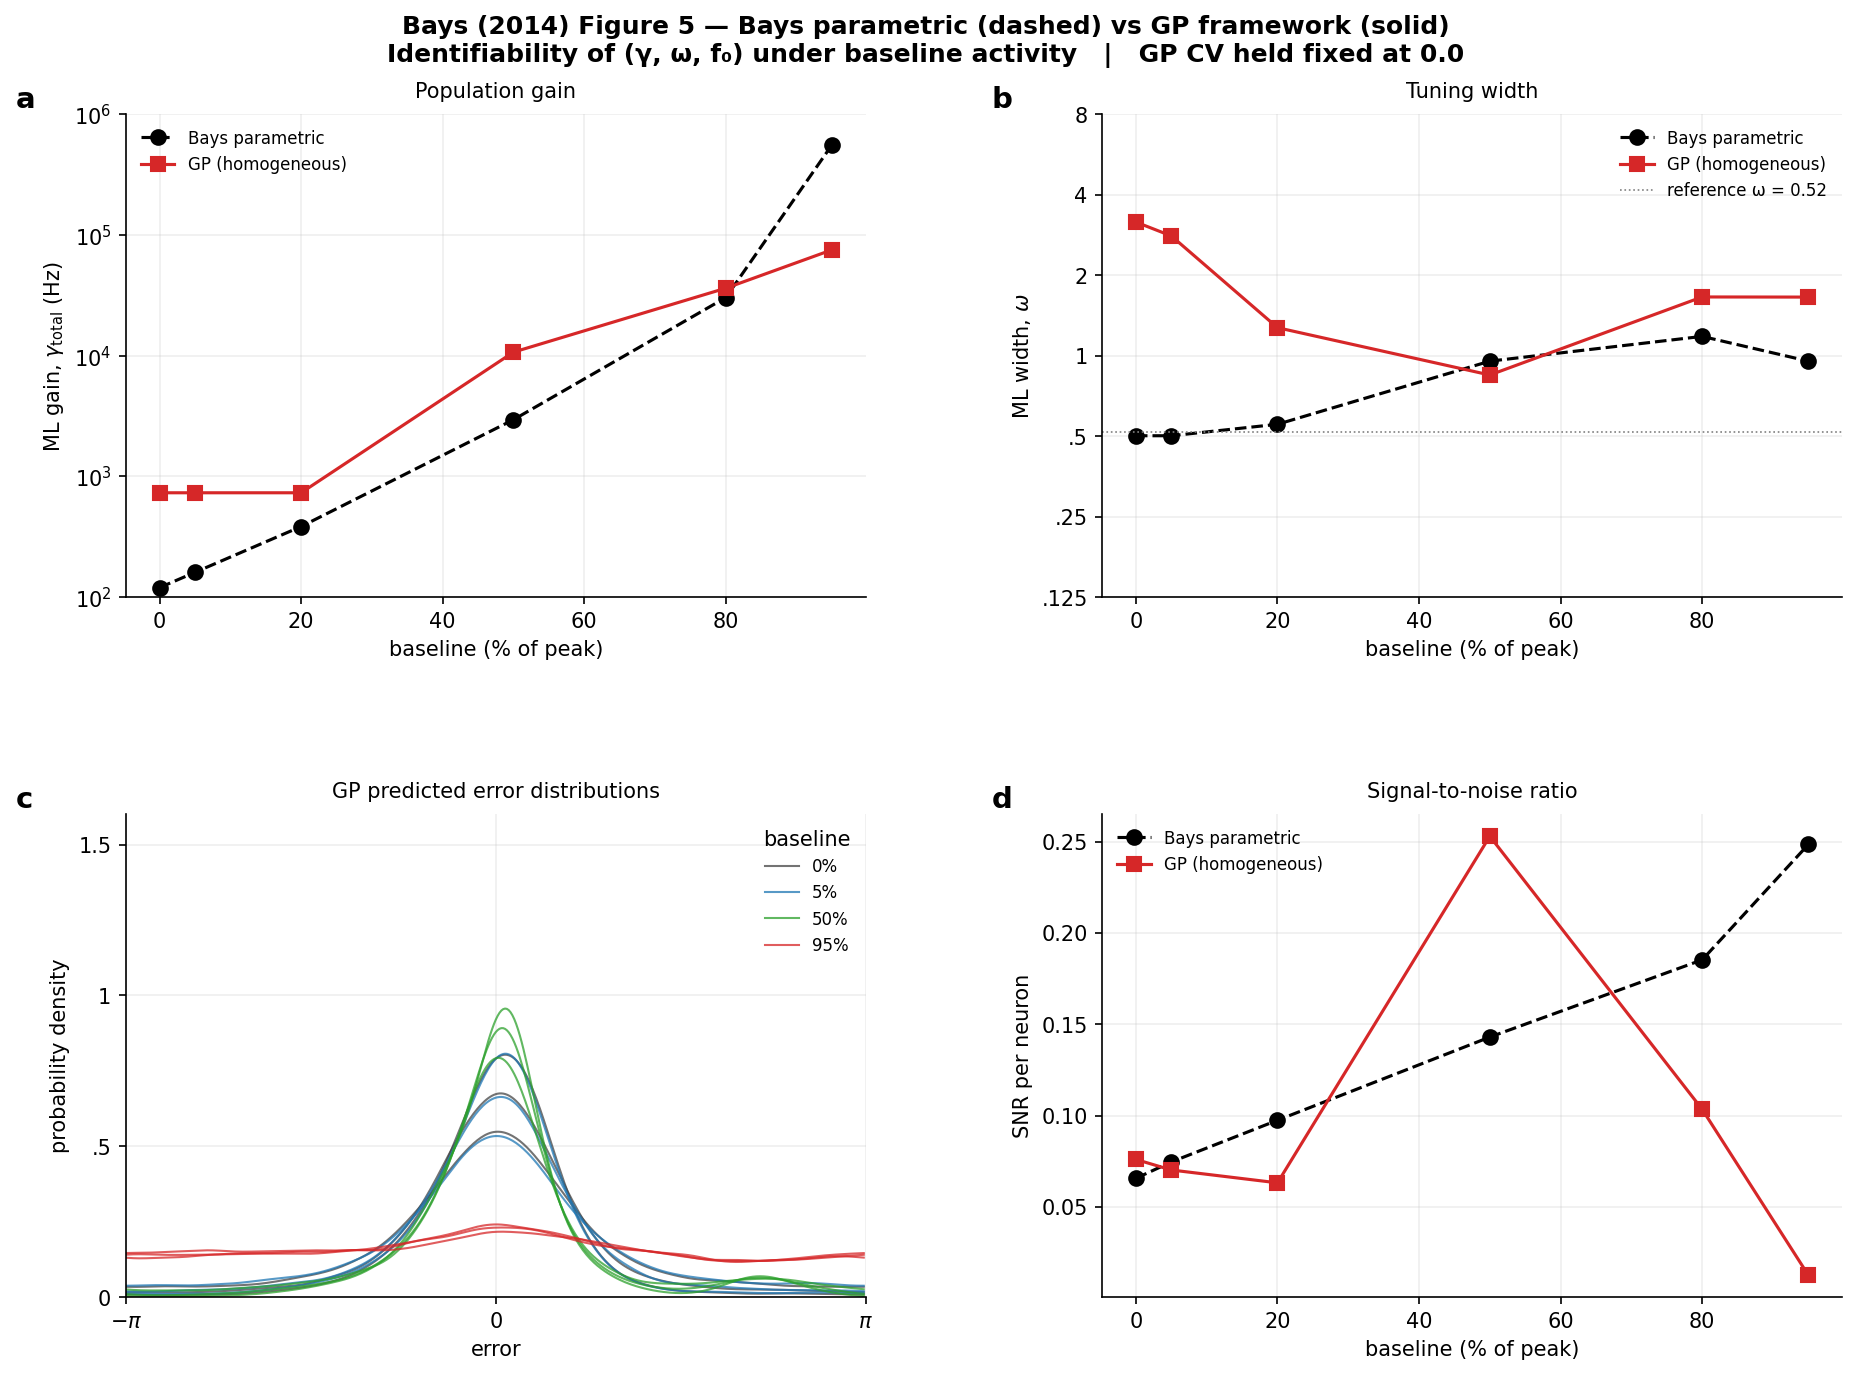


Path 2 summary:
  baseline      γ_bays        γ_gp    ω_bays      ω_gp    SNR_bays      SNR_gp
        0%       119.8       731.7     0.502     3.162      0.0657      0.0760
        5%       160.3       731.7     0.502     2.807      0.0746      0.0702
       20%       384.1       731.7     0.554     1.273      0.0975      0.0632
       50%      2951.1     10708.2     0.954     0.847      0.1430      0.2530
       80%     30338.2     36260.1     1.181     1.659      0.1853      0.1035
       95%    558467.9     75380.4     0.954     1.657      0.2485      0.0127


In [24]:
# =====================================================================
# Plot Path 2 — Bays (dashed black) + GP (solid red) overlay
# =====================================================================
# Four panels in a 2x2: γ, ω, error distributions (GP only), SNR.
# CV is held fixed at CV_GP_F5 (= 0) throughout — noted in the suptitle
# rather than given its own panel. Bays error distributions live in the
# Path 1 standalone figure; panel c here shows only the GP predictions to
# avoid duplication.

from pathlib import Path

NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR.parents[1]
RESULT_DIR   = PROJECT_ROOT / 'result_data'

print(RESULT_DIR)
print(RESULT_DIR.exists())

fig_o = plt.figure(figsize=(13, 9.5))
gs_o = gridspec.GridSpec(2, 2, hspace=0.45, wspace=0.32,
                         left=0.09, right=0.97, bottom=0.07, top=0.90)

x_pct    = [bf * 100 for bf in BAYS_BASELINE_FRACS]
gammas_b = [bays_results_f5[bf]['gamma_total'] for bf in BAYS_BASELINE_FRACS]
omegas_b = [bays_results_f5[bf]['omega']       for bf in BAYS_BASELINE_FRACS]
snrs_b   = [bays_results_f5[bf]['snr']         for bf in BAYS_BASELINE_FRACS]
gammas_g = [gp_results_f5[bf]['gamma_total']   for bf in BAYS_BASELINE_FRACS]
omegas_g = [gp_results_f5[bf]['omega']         for bf in BAYS_BASELINE_FRACS]
snrs_g   = [gp_results_f5[bf]['snr']           for bf in BAYS_BASELINE_FRACS]

BAYS_KW = dict(color='black', linestyle='--', marker='o', lw=1.5, ms=7,
               label='Bays parametric')
GP_KW   = dict(color='C3',    linestyle='-',  marker='s', lw=1.5, ms=7,
               label='GP (homogeneous)')


def style_baseline_axis(ax, label):
    """Common styling for baseline-vs-quantity panels (a, b, d)."""
    ax.set_xlabel('baseline (% of peak)')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(alpha=0.2)
    ax.text(-0.15, 1.06, label, transform=ax.transAxes,
            fontsize=14, fontweight='bold', va='top')


# ---- Panel a — γ ----
ax_a = fig_o.add_subplot(gs_o[0, 0])
ax_a.semilogy(x_pct, gammas_b, **BAYS_KW)
ax_a.semilogy(x_pct, gammas_g, **GP_KW)
ax_a.set_ylim(1e2, 1e6)
ax_a.minorticks_off()
ax_a.set_ylabel(r'ML gain, $\gamma_{\mathrm{total}}$ (Hz)')
ax_a.set_title('Population gain', fontsize=10, pad=8)
ax_a.legend(fontsize=8, frameon=False, loc='best')
style_baseline_axis(ax_a, r'$\mathbf{a}$')

# ---- Panel b — ω ----
ax_b = fig_o.add_subplot(gs_o[0, 1])
ax_b.plot(x_pct, omegas_b, **BAYS_KW)
ax_b.plot(x_pct, omegas_g, **GP_KW)
ax_b.axhline(OMEGA_GEN_F5, color='gray', lw=0.8, ls=':',
             label=f'reference ω = {OMEGA_GEN_F5}')
ax_b.set_yscale('log')
ax_b.set_ylim(0.125, 8.0)
omega_ticks = [0.125, 0.25, 0.5, 1.0, 2.0, 4.0, 8.0]
ax_b.set_yticks(omega_ticks)
ax_b.set_yticklabels(['.125', '.25', '.5', '1', '2', '4', '8'])
ax_b.minorticks_off()
ax_b.set_ylabel(r'ML width, $\omega$')
ax_b.set_title('Tuning width', fontsize=10, pad=8)
ax_b.legend(fontsize=8, frameon=False)
style_baseline_axis(ax_b, r'$\mathbf{b}$')

# ---- Panel c — error distributions (GP only) ----
# We only plot the GP-predicted error distributions here. Bays distributions
# live in the Path 1 standalone figure (Fig 5 panel c) — showing them again
# overlaid with GP curves at the same baselines would clutter the panel
# without adding information.
#
# Smoothing: vM-KDE (κ_kde = 50) on 30k trials per curve, matching the
# Path 1 panel c machinery exactly. Histogram-based density at 10k trials
# is too jagged to read at this scale; the KDE collapses the bin-counting
# noise without distorting the underlying shape.
ax_c = fig_o.add_subplot(gs_o[1, 0])

# Same Bays-literal baseline subset and colour map as the Path 1 panel c,
# so the two figures' panel c colours mean the same thing.
PANEL_C_BASELINES = [0.00, 0.05, 0.50, 0.95]
PANEL_C_SET_SIZES = [l for l in SET_SIZES_F5 if l != 1]
PANEL_C_COLORS = {
    0.00: '#444444',  # dark grey
    0.05: '#1f77b4',  # blue
    0.50: '#2ca02c',  # green
    0.95: '#d62728',  # red
}

# Sanity check: catches PANEL_C_BASELINES drifting out of sync with the swept
# baselines at plot-time rather than at dict-lookup-time.
_missing = [bf for bf in PANEL_C_BASELINES if bf not in gp_results_f5]
if _missing:
    raise ValueError(
        f"PANEL_C_BASELINES contains baselines that weren't swept: {_missing}. "
        f"Available: {sorted(gp_results_f5.keys())}.")

KAPPA_KDE_PANEL_C = 50.0
N_TRIALS_PANEL_C  = 30000
eval_pts = np.linspace(-np.pi, np.pi, 400, endpoint=False)

for bf in PANEL_C_BASELINES:
    fg = gp_results_f5[bf]
    color = PANEL_C_COLORS[bf]
    for l in PANEL_C_SET_SIZES:
        rng_p = np.random.RandomState(SEED_F5 + 88888 + int(bf*100) + l)
        errs_g = gp_forward(fg['omega'], fg['gamma_total'], bf, l,
                            N_TRIALS_PANEL_C, rng_p, T_d=T_D_F5, M=M_F5,
                            seed_pop=SEED_POP_GP)
        density = vm_kde(errs_g, eval_pts, KAPPA_KDE_PANEL_C)
        # One legend entry per baseline (only on the first set-size pass).
        ax_c.plot(eval_pts, density, color=color, lw=1.0, alpha=0.75,
                  label=f'{int(bf*100)}%' if l == PANEL_C_SET_SIZES[0] else None)

ax_c.set_xlim(-np.pi, np.pi)
ax_c.set_xticks([-np.pi, 0, np.pi])
ax_c.set_xticklabels([r'$-\pi$', '0', r'$\pi$'])
ax_c.set_ylim(0, 1.6)
ax_c.set_yticks([0, 0.5, 1.0, 1.5])
ax_c.set_yticklabels(['0', '.5', '1', '1.5'])
ax_c.set_xlabel('error')
ax_c.set_ylabel('probability density')
ax_c.set_title('GP predicted error distributions', fontsize=10, pad=8)
ax_c.legend(fontsize=8, frameon=False, loc='upper right', title='baseline')
ax_c.spines['top'].set_visible(False)
ax_c.spines['right'].set_visible(False)
ax_c.grid(alpha=0.2)
ax_c.text(-0.15, 1.06, r'$\mathbf{c}$', transform=ax_c.transAxes,
          fontsize=14, fontweight='bold', va='top')

# ---- Panel d — SNR ----
ax_d = fig_o.add_subplot(gs_o[1, 1])
ax_d.plot(x_pct, snrs_b, **BAYS_KW)
ax_d.plot(x_pct, snrs_g, **GP_KW)
ax_d.set_ylabel('SNR per neuron')
ax_d.set_title('Signal-to-noise ratio', fontsize=10, pad=8)
ax_d.legend(fontsize=8, frameon=False)
style_baseline_axis(ax_d, r'$\mathbf{d}$')

fig_o.suptitle(
    'Bays (2014) Figure 5 — Bays parametric (dashed) vs GP framework (solid)\n'
    'Identifiability of (γ, ω, f₀) under baseline activity   |   GP CV held fixed at '
    f'{CV_GP_F5}',
    fontsize=12, fontweight='bold', y=0.97)

plt.savefig(RESULT_DIR / 'bays_fig5_path2_overlay.png', dpi=150)
plt.show()

print('\nPath 2 summary:')
print(f'{"baseline":>10s}  '
      f'{"γ_bays":>10s}  {"γ_gp":>10s}  '
      f'{"ω_bays":>8s}  {"ω_gp":>8s}  '
      f'{"SNR_bays":>10s}  {"SNR_gp":>10s}')
for bf in BAYS_BASELINE_FRACS:
    rb = bays_results_f5[bf]; rg = gp_results_f5[bf]
    print(f'{bf*100:>9.0f}%  '
          f'{rb["gamma_total"]:>10.1f}  {rg["gamma_total"]:>10.1f}  '
          f'{rb["omega"]:>8.3f}  {rg["omega"]:>8.3f}  '
          f'{rb["snr"]:>10.4f}  {rg["snr"]:>10.4f}')